<a href="https://colab.research.google.com/github/shafiq73/2024/blob/main/Osman.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
df.head()

,Province,Districts,Reporting Health Facility,EPID No,Lab. ID,Age In Month,Sex,"Address, UC&Tehsil/Taluka",Date of Onset,No of vaccine doses,Date of Last Vaccination,Date Specimen Collected,Date Send To Lab,Date Specimen Received,Type Of Specimen,Sample Condition,Test Date,Measles IgM Results,S.No
0,KPK,Mansehra,ATH ATD,CIF/1301833,27980,-,F,Baro Bandi,2025-06-25 00:00:00,Zero,-,2025-06-28 00:00:00,2025-06-28 00:00:00,2025-07-01,BLOOD,GOOD,2025-07-02,POSITIVE,1
1,KPK,Mansehra,ATH ATD,CIF/1301831,27981,-,F,Jabbar Dawli,2025-06-25 00:00:00,Zero,-,2025-06-28 00:00:00,2025-06-28 00:00:00,2025-07-01,BLOOD,GOOD,2025-07-02,POSITIVE,2
2,KPK,Mansehra,ATH ATD,CIF/1301834,27984,-,F,Naka Pani Oghi,2025-06-26 00:00:00,Zero,-,2025-06-28 00:00:00,2025-06-28 00:00:00,2025-07-01,BLOOD,GOOD,2025-07-02,POSITIVE,3
3,KPK,Mansehra,ATH ATD,CIF/1302106,28320,-,M,Band Manoor Balakot,2025-06-30 00:00:00,Zero,-,2025-07-02 00:00:00,2025-07-02 00:00:00,2025-07-03,BLOOD,GOOD,2025-07-04,POSITIVE,4
4,KPK,Mansehra,ATH ATD,CIF/1302109,28322,-,F,Mohri Sat Ari Balakot,2025-06-30 00:00:00,Zero,-,2025-07-02 00:00:00,2025-07-02 00:00:00,2025-07-03,BLOOD,GOOD,2025-07-04,POSITIVE,5


In [4]:
df.columns

Index(['Province', 'Districts', 'Reporting Health Facility', 'EPID No',
       'Lab. ID ', 'Age In Month', 'Sex', 'Address, UC&Tehsil/Taluka ',
       'Date of Onset', 'No of vaccine doses ', 'Date of Last Vaccination',
       'Date Specimen Collected', 'Date  Send To Lab',
       'Date Specimen Received', 'Type Of Specimen ', 'Sample Condition',
       'Test Date', 'Measles IgM Results', 'S.No'],
      dtype='object')

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 224 entries, 0 to 223
Data columns (total 19 columns):
 #   Column                      Non-Null Count  Dtype         
---  ------                      --------------  -----         
 0   Province                    224 non-null    object        
 1   Districts                   224 non-null    object        
 2   Reporting Health Facility   224 non-null    object        
 3   EPID No                     217 non-null    object        
 4   Lab. ID                     224 non-null    int64         
 5   Age In Month                224 non-null    object        
 6   Sex                         224 non-null    object        
 7   Address, UC&Tehsil/Taluka   224 non-null    object        
 8   Date of Onset               224 non-null    object        
 9   No of vaccine doses         224 non-null    object        
 10  Date of Last Vaccination    220 non-null    object        
 11  Date Specimen Collected     224 non-null    object        

In [ ]:
import pandas as pd
import plotly.express as px

# Dataset load
df = pd.read_excel("Measles Serology_Manshera 2025.xlsx")

# Column name clean karna (spaces remove)
df.columns = df.columns.str.strip()

# Target column
col = "Measles IgM Results"

# Count
counts = df[col].value_counts()

# Percentage
percent = (counts / len(df)) * 100

# Combine into DataFrame
result_df = pd.DataFrame({
    "Result": counts.index,
    "Count": counts.values,
    "Percentage": percent.values
})

print("\n📊 Measles Results Summary:\n")
print(result_df)

# 🎯 PIE CHART
fig = px.pie(
    result_df,
    names="Result",
    values="Count",
    title="🦠 Measles Positive vs Negative Distribution",
    hole=0.4
)

# Percentage labels show karne ke liye
fig.update_traces(textinfo="percent+label")

fig.show()


📊 Measles Results Summary:

     Result  Count  Percentage
0  POSITIVE    158   70.535714
1  NEGATIVE     66   29.464286


In [6]:
import pandas as pd
import plotly.express as px

# 1. Dataset load
try:
    df = pd.read_excel("Measles Serology_Manshera 2025.xlsx")
    df.columns = df.columns.str.strip()
    col = "Measles IgM Results"

    # 2. Count & Percentage Calculation
    counts = df[col].value_counts()
    percent = (counts / len(df)) * 100

    result_df = pd.DataFrame({
        "Result": counts.index,
        "Count": counts.values,
        "Percentage": percent.values
    })

    # 3. Custom Color Map (Colors define karein)
    color_map = {
        "Positive": "#E74C3C", # Red for positive
        "Negative": "#2ECC71", # Green for negative
        "Equivocal": "#F1C40F" # Yellow if any
    }

    # 4. 🎯 BEAUTIFUL & COMPACT PIE CHART
    fig = px.pie(
        result_df,
        names="Result",
        values="Count",
        title="🦠 Measles IgM Distribution (2025)",
        hole=0.5, # Donut style
        color="Result",
        color_discrete_map=color_map,
        template="plotly_white"
    )

    # Styling updates
    fig.update_traces(
        textinfo="percent+label",
        textfont_size=14,
        marker=dict(line=dict(color='#FFFFFF', width=2)), # White border between slices
        pull=[0.1 if res == "Positive" else 0 for res in result_df["Result"]] # Extract Positive slice
    )

    fig.update_layout(
        width=450,    # Chart ki width choti kar di
        height=450,   # Chart ki height choti kar di
        title_x=0.5,  # Title center mein
        margin=dict(t=50, b=20, l=20, r=20), # Faltu space khatam
        showlegend=False # Labels andar hain, toh legend ki zaroorat nahi
    )

    # Show the result
    print("\n📊 Measles Results Summary:\n")
    print(result_df)
    fig.show()

except FileNotFoundError:
    print("Error: File nahi mili. Baraye meherbani check karein ke file name durust hai.")


📊 Measles Results Summary:

     Result  Count  Percentage
0  POSITIVE    158   70.535714
1  NEGATIVE     66   29.464286


In [ ]:
import pandas as pd
import plotly.express as px

# Load dataset
df = pd.read_excel("Measles Serology_Manshera 2025.xlsx")

# Column names clean
df.columns = df.columns.str.strip()

# Important columns
gender_col = "Sex"
result_col = "Measles IgM Results"

# Clean values (important step)
df[gender_col] = df[gender_col].str.strip().str.upper()
df[result_col] = df[result_col].str.strip().str.upper()

# ==============================
# GROUPING (COUNT)
# ==============================
grouped = df.groupby([gender_col, result_col]).size().reset_index(name="Count")

# ==============================
# PERCENTAGE CALCULATION
# ==============================
total_gender = grouped.groupby(gender_col)["Count"].transform("sum")
grouped["Percentage"] = (grouped["Count"] / total_gender) * 100

print("\n📊 Gender-wise Measles Results:\n")
print(grouped)

# ==============================
# BAR CHART
# ==============================
fig = px.bar(
    grouped,
    x=gender_col,
    y="Count",
    color=result_col,
    barmode="group",
    text=grouped["Percentage"].round(1).astype(str) + "%",
    title="🦠 Gender-wise Measles Results (Count + %)",
    template="plotly_white"
)

# Text labels on bars
fig.update_traces(textposition='outside')

# Layout improvement
fig.update_layout(
    title_x=0.5,
    xaxis_title="Gender",
    yaxis_title="Count",
    legend_title="Result"
)

fig.show()


📊 Gender-wise Measles Results:

  Sex Measles IgM Results  Count  Percentage
0   F            NEGATIVE     28   25.688073
1   F            POSITIVE     81   74.311927
2   M            NEGATIVE     38   33.043478
3   M            POSITIVE     77   66.956522


In [7]:
import pandas as pd
import plotly.express as px

# 1. Dataset Load (Assuming file exists)
df = pd.read_excel("Measles Serology_Manshera 2025.xlsx")
df.columns = df.columns.str.strip()

gender_col = "Sex"
result_col = "Measles IgM Results"

# 2. Cleaning
df[gender_col] = df[gender_col].str.strip().str.upper()
df[result_col] = df[result_col].str.strip().str.upper()

# 3. Grouping & Percentage
grouped = df.groupby([gender_col, result_col]).size().reset_index(name="Count")
total_gender = grouped.groupby(gender_col)["Count"].transform("sum")
grouped["Percentage"] = (grouped["Count"] / total_gender) * 100

# 4. Custom Color Palette
color_map = {
    "POSITIVE": "#E74C3C", # Crimson Red
    "NEGATIVE": "#16A085", # Teal Green
    "EQUIVOCAL": "#F39C12" # Orange/Yellow
}

# 5. 📊 BEAUTIFUL & COMPACT BAR CHART
fig = px.bar(
    grouped,
    x=gender_col,
    y="Count",
    color=result_col,
    barmode="group",
    text=grouped["Percentage"].apply(lambda x: f"{x:.1f}%"),
    title="<b>Gender-wise Measles Analysis</b>",
    color_discrete_map=color_map,
    template="plotly_white",
    category_orders={gender_col: ["MALE", "FEMALE"]} # Gender order set karein
)

# 6. Design Fine-tuning
fig.update_traces(
    textposition='outside',
    textfont_size=12,
    marker_line_color='white', # Bar borders
    marker_line_width=1.5,
    opacity=0.85
)

fig.update_layout(
    width=600,             # Choti width
    height=400,            # Munasib height
    bargap=0.25,           # Bars ke darmiyan space
    title_x=0.5,           # Title center mein
    title_font_size=18,
    xaxis_title="<b>Patient Gender</b>",
    yaxis_title="<b>Number of Cases</b>",
    legend_title="Result Status",
    margin=dict(t=60, b=40, l=50, r=30), # Side margins kam kiye
    legend=dict(orientation="h", yanchor="bottom", y=1.02, xanchor="right", x=1) # Legend top par
)

fig.show()

In [15]:
import pandas as pd
import plotly.express as px

# 1. Dataset Load & Cleaning
df = pd.read_excel("Measles Serology_Manshera 2025.xlsx")
df.columns = df.columns.str.strip()

gender_col = "Sex"
result_col = "Measles IgM Results"

df[gender_col] = df[gender_col].str.strip().str.upper()
df[result_col] = df[result_col].str.strip().str.upper()

# 2. Grouping & Percentage Calculation
grouped = df.groupby([gender_col, result_col]).size().reset_index(name="Count")
total_gender = grouped.groupby(gender_col)["Count"].transform("sum")
grouped["Percentage"] = (grouped["Count"] / total_gender) * 100

# 3. Academic Color Palette
color_map = {
    "POSITIVE": "#C0392B", # Academic Red
    "NEGATIVE": "#2E86C1", # Academic Blue
    "EQUIVOCAL": "#F1C40F" # Academic Yellow
}

# 4. 🎓 THESIS STANDARD BAR CHART
fig = px.bar(
    grouped,
    x=gender_col,
    y="Count",
    color=result_col,
    barmode="group",
    # Text mein Count aur Percentage dono shamil hain for thesis detail
    text=grouped.apply(lambda x: f"{int(x['Count'])}<br>({x['Percentage']:.1f}%)", axis=1),
    title="<b>Figure 5: Gender-wise Distribution of Measles IgM Serology Results</b>",
    color_discrete_map=color_map,
    template="plotly_white",
    category_orders={gender_col: ["MALE", "FEMALE"]}
)

# 5. Professional Styling for Research
fig.update_traces(
    textposition='outside',
    textfont=dict(size=13, family="Times New Roman", color="black"),
    marker_line_color='black', # Formal black borders
    marker_line_width=1,
    opacity=0.9
)

fig.update_layout(
    width=950,               # Thesis Standard Width
    height=600,              # Thesis Standard Height
    bargap=0.3,              # Professional spacing
    title_x=0.5,
    title_font=dict(size=20, family="Times New Roman"),
    xaxis=dict(
        title="<b>Patient Gender</b>",
        titlefont=dict(size=18, family="Times New Roman"),
        tickfont=dict(size=16, family="Times New Roman")
    ),
    yaxis=dict(
        title="<b>Number of Cases (n)</b>",
        titlefont=dict(size=18, family="Times New Roman"),
        tickfont=dict(size=16, family="Times New Roman"),
        gridcolor='LightGray'
    ),
    legend=dict(
        title="<b>Serology Result</b>",
        orientation="h",
        yanchor="bottom", y=-0.25, # Legend moved to bottom for thesis
        xanchor="center", x=0.5,
        font=dict(size=14, family="Times New Roman"),
        bordercolor="Black", borderwidth=1
    ),
    margin=dict(t=80, b=120, l=80, r=40)
)

fig.show()

# Quick Statistical Summary for Thesis Table
print("\n📊 Statistical Summary for Table Construction:")
pivot_table = df.pivot_table(index=gender_col, columns=result_col, aggfunc='size', fill_value=0)
print(pivot_table)


📊 Statistical Summary for Table Construction:
Measles IgM Results  NEGATIVE  POSITIVE
Sex                                    
F                          28        81
M                          38        77


In [ ]:
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go

# Load dataset
df = pd.read_excel("Measles Serology_Manshera 2025.xlsx")

# Clean columns
df.columns = df.columns.str.strip()

date_col = "Date of Onset"
result_col = "Measles IgM Results"

# Clean values
df[result_col] = df[result_col].str.strip().str.upper()

# Convert date
df[date_col] = pd.to_datetime(df[date_col], dayfirst=True, errors='coerce')

# Filter July–December 2025
df = df[
    (df[date_col] >= "2025-07-01") &
    (df[date_col] <= "2025-12-31")
]

# Month extract
df["Month"] = df[date_col].dt.strftime("%B")

# Total cases
total_cases = df.groupby("Month").size().reset_index(name="Total")

# Positive cases
positive_cases = df[df[result_col] == "POSITIVE"] \
    .groupby("Month").size().reset_index(name="Positive")

# Merge
monthly = pd.merge(total_cases, positive_cases, on="Month", how="left").fillna(0)

# Percentage
monthly["Positive %"] = (monthly["Positive"] / monthly["Total"]) * 100

# Month order
month_order = ["July", "August", "September", "October", "November", "December"]
monthly["Month"] = pd.Categorical(monthly["Month"], categories=month_order, ordered=True)
monthly = monthly.sort_values("Month")

print("\n📊 Monthly Summary:\n")
print(monthly)

# =========================
# 🔥 CHART (BAR + LINE)
# =========================
fig = go.Figure()

# Total cases (Bar)
fig.add_trace(go.Bar(
    x=monthly["Month"],
    y=monthly["Total"],
    name="Total Cases"
))

# Positive cases (Bar)
fig.add_trace(go.Bar(
    x=monthly["Month"],
    y=monthly["Positive"],
    name="Positive Cases"
))

# 🔥 Trend Line (Total)
fig.add_trace(go.Scatter(
    x=monthly["Month"],
    y=monthly["Total"],
    mode='lines+markers',
    name='Trend (Total)',
    line=dict(width=3)
))

# Layout
fig.update_layout(
    title="🦠 Monthly Measles Trend (July–Dec 2025)",
    barmode='group',
    title_x=0.5,
    xaxis_title="Month",
    yaxis_title="Cases"
)

fig.show()

# =========================
# 🔥 INSIGHTS AUTO PRINT
# =========================
max_month = monthly.loc[monthly["Total"].idxmax(), "Month"]
min_month = monthly.loc[monthly["Total"].idxmin(), "Month"]

print(f"\n🔥 Highest cases in: {max_month}")
print(f"📉 Lowest cases in: {min_month}")


📊 Monthly Summary:

       Month  Total  Positive  Positive %
2       July     38        27   71.052632
0     August     38        29   76.315789
5  September     27        22   81.481481
4    October     27        18   66.666667
3   November     40        30   75.000000
1   December     45        25   55.555556



🔥 Highest cases in: December
📉 Lowest cases in: September


In [8]:
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go

# 1. Dataset load & Cleaning
df = pd.read_excel("Measles Serology_Manshera 2025.xlsx")
df.columns = df.columns.str.strip()

date_col = "Date of Onset"
result_col = "Measles IgM Results"
df[result_col] = df[result_col].str.strip().str.upper()
df[date_col] = pd.to_datetime(df[date_col], dayfirst=True, errors='coerce')

# July–December 2025 filter
df = df[(df[date_col] >= "2025-07-01") & (df[date_col] <= "2025-12-31")]
df["Month"] = df[date_col].dt.strftime("%B")

# 2. Aggregation
total_cases = df.groupby("Month").size().reset_index(name="Total")
positive_cases = df[df[result_col] == "POSITIVE"].groupby("Month").size().reset_index(name="Positive")
monthly = pd.merge(total_cases, positive_cases, on="Month", how="left").fillna(0)

# Month order correct karein
month_order = ["July", "August", "September", "October", "November", "December"]
monthly["Month"] = pd.Categorical(monthly["Month"], categories=month_order, ordered=True)
monthly = monthly.sort_values("Month")

# 3. 🔥 BEAUTIFUL & COMPACT MULTI-CHART
fig = go.Figure()

# Total Cases (Bar) - Soft Blue
fig.add_trace(go.Bar(
    x=monthly["Month"], y=monthly["Total"],
    name="Total Cases",
    marker_color='#AED6F1',
    marker_line_color='#2E86C1',
    marker_line_width=1.5,
    opacity=0.7
))

# Positive Cases (Bar) - Muted Red
fig.add_trace(go.Bar(
    x=monthly["Month"], y=monthly["Positive"],
    name="Positive Cases",
    marker_color='#E74C3C',
    text=monthly["Positive"].astype(int),
    textposition='inside'
))

# Trend Line (Total) - Dark Blue Line
fig.add_trace(go.Scatter(
    x=monthly["Month"], y=monthly["Total"],
    mode='lines+markers',
    name='Total Trend',
    line=dict(color='#21618C', width=3, dash='dot'),
    marker=dict(size=8, symbol='diamond')
))

# 4. Layout Updates
fig.update_layout(
    title="<b>Monthly Measles Trend (July–Dec 2025)</b>",
    title_x=0.5,
    width=650,
    height=420,
    barmode='group',
    template="plotly_white",
    legend=dict(orientation="h", yanchor="bottom", y=1.02, xanchor="right", x=1),
    margin=dict(t=80, b=40, l=50, r=30),
    xaxis_title="Month",
    yaxis_title="Count of Cases",
    bargap=0.2,
    bargroupgap=0.1
)

# Y-axis styling
fig.update_yaxes(showgrid=True, gridwidth=1, gridcolor='LightGray')

fig.show()

# =========================
# 🔥 INSIGHTS AUTO PRINT
# =========================
max_month = monthly.loc[monthly["Total"].idxmax(), "Month"]
min_month = monthly.loc[monthly["Total"].idxmin(), "Month"]
total_pos = int(monthly["Positive"].sum())

print(f"\n📊 --- QUICK INSIGHTS ---")
print(f"🔥 Peak Month: {max_month}")
print(f"📉 Lowest Month: {min_month}")
print(f"✅ Total Positive Cases: {total_pos}")


📊 --- QUICK INSIGHTS ---
🔥 Peak Month: December
📉 Lowest Month: September
✅ Total Positive Cases: 151


In [10]:
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go

# 1. Dataset load & Cleaning (Assuming df is already loaded as per your code)
# ... (Keep your data processing code same here) ...

# 3. 🔥 THESIS STANDARD SIZE & STYLE CHART
fig = go.Figure()

# Total Cases (Bar)
fig.add_trace(go.Bar(
    x=monthly["Month"], y=monthly["Total"],
    name="Total Suspected Cases",
    marker_color='#D6EAF8', # Soft color for academic look
    marker_line_color='#2E86C1',
    marker_line_width=1.5,
    opacity=0.85
))

# Positive Cases (Bar)
fig.add_trace(go.Bar(
    x=monthly["Month"], y=monthly["Positive"],
    name="Confirmed Positive Cases",
    marker_color='#C0392B', # Standard Crimson for Positive
    text=monthly["Positive"].astype(int),
    textposition='auto',
    textfont=dict(size=14, color='black') # Clearer text for print
))

# Trend Line (Total)
fig.add_trace(go.Scatter(
    x=monthly["Month"], y=monthly["Total"],
    mode='lines+markers',
    name='Epidemic Trend',
    line=dict(color='#1B4F72', width=4), # Thicker line for thesis visibility
    marker=dict(size=10, symbol='circle', line=dict(width=2, color='white'))
))

# 4. 🎓 Thesis Layout Adjustments
fig.update_layout(
    title=dict(
        text="<b>Figure 1: Monthly Distribution of Measles Cases (July–Dec 2025)</b>",
        x=0.5,
        font=dict(size=20, family="Times New Roman") # Academic Font
    ),
    width=950,   # Thesis Standard Width
    height=600,  # Thesis Standard Height
    barmode='group',
    template="plotly_white",
    legend=dict(
        orientation="h",
        yanchor="bottom", y=-0.25, # Legend niche move kar di taake chart area bara ho
        xanchor="center", x=0.5,
        font=dict(size=14),
        bordercolor="Black", borderwidth=1 # Formal Box for legend
    ),
    margin=dict(t=80, b=100, l=80, r=40), # Professional margins
    xaxis=dict(
        title="<b>Reporting Month</b>",
        titlefont=dict(size=16),
        tickfont=dict(size=14)
    ),
    yaxis=dict(
        title="<b>Number of Cases (n)</b>",
        titlefont=dict(size=16),
        tickfont=dict(size=14),
        gridcolor='LightGray'
    )
)

fig.show()

# High-Resolution Export Command (Optional)
# fig.write_image("measles_trend_2025.png", scale=3) # Scale 3 se image quality 3x ho jati hai

In [ ]:
import pandas as pd
import numpy as np
import plotly.graph_objects as go

df = pd.read_excel("Measles Serology_Manshera 2025.xlsx")

# Clean
df.columns = df.columns.str.strip()

age_col = "Age In Month"
result_col = "Measles IgM Results"

df[result_col] = df[result_col].str.strip().str.upper()
df[age_col] = pd.to_numeric(df[age_col], errors='coerce')

# ==============================
# AGE GROUPS
# ==============================
bins = [0, 6, 12, 24, 60, 120, 240]
labels = ["0-6m", "6-12m", "1-2y", "2-5y", "5-10y", "10-20y"]

df["Age Group"] = pd.cut(df[age_col], bins=bins, labels=labels)

# ==============================
# GROUPING (⚠ observed=False fix)
# ==============================
total = df.groupby("Age Group", observed=False).size().reset_index(name="Total")

positive = df[df[result_col] == "POSITIVE"] \
    .groupby("Age Group", observed=False).size().reset_index(name="Positive")

# ==============================
# MERGE (NO fillna issue)
# ==============================
age_df = pd.merge(total, positive, on="Age Group", how="left")

# 🔥 IMPORTANT FIX
age_df["Positive"] = age_df["Positive"].fillna(0)

# Percentage
age_df["Positivity %"] = (age_df["Positive"] / age_df["Total"]) * 100

print(age_df)

# ==============================
# CHART
# ==============================
fig = go.Figure()

fig.add_bar(x=age_df["Age Group"], y=age_df["Total"], name="Total")
fig.add_bar(x=age_df["Age Group"], y=age_df["Positive"], name="Positive")

fig.add_trace(go.Scatter(
    x=age_df["Age Group"],
    y=age_df["Positivity %"],
    mode='lines+markers',
    name="Positivity %"
))

fig.update_layout(
    title="Age-wise Measles Positivity",
    barmode="group"
)

fig.show()

  Age Group  Total  Positive  Positivity %
0      0-6m     18        11     61.111111
1     6-12m     41        25     60.975610
2      1-2y     16        15     93.750000
3      2-5y     31        25     80.645161
4     5-10y      9         7     77.777778
5    10-20y      3         2     66.666667


In [11]:
import pandas as pd
import numpy as np
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# 1. Processing (Keep your logic as is)
df = pd.read_excel("Measles Serology_Manshera 2025.xlsx")
df.columns = df.columns.str.strip()

age_col = "Age In Month"
result_col = "Measles IgM Results"
df[result_col] = df[result_col].str.strip().str.upper()
df[age_col] = pd.to_numeric(df[age_col], errors='coerce')

bins = [0, 6, 12, 24, 60, 120, 240]
labels = ["0-6m", "6-12m", "1-2y", "2-5y", "5-10y", "10-20y"]
df["Age Group"] = pd.cut(df[age_col], bins=bins, labels=labels)

total = df.groupby("Age Group", observed=False).size().reset_index(name="Total")
positive = df[df[result_col] == "POSITIVE"].groupby("Age Group", observed=False).size().reset_index(name="Positive")

age_df = pd.merge(total, positive, on="Age Group", how="left")
age_df["Positive"] = age_df["Positive"].fillna(0)
age_df["Positivity %"] = (age_df["Positive"] / age_df["Total"]) * 100

# 2. 🎓 THESIS STANDARD DUAL-AXIS CHART
fig = make_subplots(specs=[[{"secondary_y": True}]])

# Total Cases Bar (Professional Slate Grey)
fig.add_trace(
    go.Bar(
        x=age_df["Age Group"],
        y=age_df["Total"],
        name="Total Suspected Cases",
        marker_color='#D5D8DC',
        marker_line_color='#2C3E50',
        marker_line_width=1.5,
        opacity=0.8
    ),
    secondary_y=False
)

# Positive Cases Bar (Professional Crimson)
fig.add_trace(
    go.Bar(
        x=age_df["Age Group"],
        y=age_df["Positive"],
        name="Confirmed Positive Cases",
        marker_color='#C0392B',
        text=age_df["Positive"].astype(int),
        textposition='auto',
        textfont=dict(size=13)
    ),
    secondary_y=False
)

# Positivity Percentage Line (Vibrant Gold/Amber)
fig.add_trace(
    go.Scatter(
        x=age_df["Age Group"],
        y=age_df["Positivity %"],
        name="Positivity Rate (%)",
        mode='lines+markers+text',
        text=age_df["Positivity %"].round(1).astype(str) + "%",
        textposition="top center",
        line=dict(color='#F1C40F', width=4),
        marker=dict(size=10, symbol='diamond', line=dict(width=1, color='black'))
    ),
    secondary_y=True
)

# 3. 🎓 Academic Layout Styling
fig.update_layout(
    title=dict(
        text="<b>Figure 2: Age-Specific Measles Prevalence and Positivity Rate</b>",
        x=0.5,
        font=dict(size=20, family="Times New Roman")
    ),
    width=950,
    height=600,
    barmode="group",
    template="plotly_white",
    legend=dict(
        orientation="h",
        yanchor="bottom", y=-0.25,
        xanchor="center", x=0.5,
        font=dict(size=14),
        bordercolor="Black", borderwidth=1
    ),
    margin=dict(t=100, b=100, l=80, r=80),
    bargap=0.25
)

# Axis Titles
fig.update_xaxes(title_text="<b>Age Category</b>", titlefont_size=16, tickfont_size=14)
fig.update_yaxes(title_text="<b>Frequency of Cases (n)</b>", secondary_y=False, titlefont_size=16)
fig.update_yaxes(title_text="<b>Positivity Rate (%)</b>", secondary_y=True, range=[0, 115], titlefont_size=16)

fig.show()

In [ ]:
import pandas as pd
import plotly.express as px

# Load dataset
df = pd.read_excel("Measles Serology_Manshera 2025.xlsx")

# Clean columns
df.columns = df.columns.str.strip()

age_col = "Age In Month"
vaccine_col = "No of vaccine doses"

# Clean data
df[age_col] = pd.to_numeric(df[age_col], errors='coerce')
df[vaccine_col] = pd.to_numeric(df[vaccine_col], errors='coerce')

# ==============================
# AGE GROUP (<9 vs >=9)
# ==============================
df["Age Group"] = df[age_col].apply(lambda x: "<9 months" if x < 9 else ">=9 months")

# ==============================
# VACCINATION STATUS
# ==============================
def vaccine_status(x):
    if pd.isna(x):
        return "Unknown"
    elif x == 0:
        return "Not Vaccinated"
    else:
        return "Vaccinated"

df["Vaccination Status"] = df[vaccine_col].apply(vaccine_status)

# ==============================
# TABLE (COUNT)
# ==============================
table = pd.crosstab(df["Age Group"], df["Vaccination Status"])

# ==============================
# PERCENTAGE TABLE
# ==============================
percent_table = (table.div(table.sum(axis=1), axis=0) * 100).round(2)

print("\n📊 Vaccination Status (Counts):\n")
print(table)

print("\n📊 Vaccination Status (%):\n")
print(percent_table)

# ==============================
# BAR CHART (COUNT)
# ==============================
table_reset = table.reset_index().melt(id_vars="Age Group")

fig = px.bar(
    table_reset,
    x="Age Group",
    y="value",
    color="Vaccination Status",
    barmode="group",
    text="value",
    title="💉 Vaccination Status by Age Group (<9 vs ≥9 months)",
    template="plotly_white"
)

fig.update_traces(textposition='outside')

fig.update_layout(
    title_x=0.5,
    xaxis_title="Age Group",
    yaxis_title="Number of Patients"
)

fig.show()


📊 Vaccination Status (Counts):

Vaccination Status  Unknown
Age Group                  
<9 months                38
>=9 months              186

📊 Vaccination Status (%):

Vaccination Status  Unknown
Age Group                  
<9 months             100.0
>=9 months            100.0


In [12]:
import pandas as pd
import plotly.express as px

# 1. Processing (Aapka logic bilkul sahi hai)
df = pd.read_excel("Measles Serology_Manshera 2025.xlsx")
df.columns = df.columns.str.strip()

age_col = "Age In Month"
vaccine_col = "No of vaccine doses"

df[age_col] = pd.to_numeric(df[age_col], errors='coerce')
df[vaccine_col] = pd.to_numeric(df[vaccine_col], errors='coerce')

df["Age Group"] = df[age_col].apply(lambda x: "<9 months" if x < 9 else "≥9 months")

def vaccine_status(x):
    if pd.isna(x): return "Unknown"
    elif x == 0: return "Unvaccinated"
    else: return "Vaccinated"

df["Vaccination Status"] = df[vaccine_col].apply(vaccine_status)

# Table prepare karein
table = pd.crosstab(df["Age Group"], df["Vaccination Status"])
table_reset = table.reset_index().melt(id_vars="Age Group")

# 2. 🎓 THESIS STANDARD VACCINATION CHART
# Custom Colors: Academic look ke liye
color_map = {
    "Vaccinated": "#2E86C1",    # Formal Blue
    "Unvaccinated": "#C0392B",  # Formal Red
    "Unknown": "#BDC3C7"       # Neutral Grey
}

fig = px.bar(
    table_reset,
    x="Age Group",
    y="value",
    color="Vaccination Status",
    barmode="group",
    text="value",
    title="<b>Figure 3: Vaccination Status Distribution by Age Eligibility</b>",
    color_discrete_map=color_map,
    template="plotly_white",
    category_orders={"Age Group": ["<9 months", "≥9 months"]} # Order set karein
)

# 3. 🎓 Styling for Research Publication
fig.update_traces(
    textposition='outside',
    textfont=dict(size=14, family="Times New Roman"),
    marker_line_color='black',
    marker_line_width=1
)

fig.update_layout(
    width=950,
    height=600,
    title=dict(
        x=0.5,
        font=dict(size=22, family="Times New Roman")
    ),
    legend=dict(
        orientation="h",
        yanchor="bottom", y=-0.25,
        xanchor="center", x=0.5,
        font=dict(size=14, family="Times New Roman"),
        bordercolor="Black", borderwidth=1
    ),
    margin=dict(t=100, b=120, l=80, r=40),
    xaxis=dict(
        title="<b>Patient Age Group</b>",
        titlefont=dict(size=18, family="Times New Roman"),
        tickfont=dict(size=16, family="Times New Roman")
    ),
    yaxis=dict(
        title="<b>Frequency of Patients (n)</b>",
        titlefont=dict(size=18, family="Times New Roman"),
        tickfont=dict(size=16, family="Times New Roman"),
        gridcolor='LightGray'
    ),
    bargap=0.2,
    bargroupgap=0.05
)

fig.show()

# Quick Insights for Discussion Section
print("\n📊 --- THESIS DATA SUMMARY ---")
print(table)


📊 --- THESIS DATA SUMMARY ---
Vaccination Status  Unknown
Age Group                  
<9 months                38
≥9 months               186


In [ ]:
df.columns

Index(['Province', 'Districts', 'Reporting Health Facility', 'EPID No',
       'Lab. ID', 'Age In Month', 'Sex', 'Address, UC&Tehsil/Taluka',
       'Date of Onset', 'No of vaccine doses', 'Date of Last Vaccination',
       'Date Specimen Collected', 'Date  Send To Lab',
       'Date Specimen Received', 'Type Of Specimen', 'Sample Condition',
       'Test Date', 'Measles IgM Results', 'S.No', 'Pie_Status'],
      dtype='object')

In [ ]:
# Column name ko clean karne ke baad count lena
df.columns = df.columns.str.strip()
counts = df['No of vaccine doses'].value_counts()

print(counts)

Series([], Name: count, dtype: int64)


In [ ]:
# Column name ko clean karne ke baad count lena
df.columns = df.columns.str.strip()
counts = df['Date of Last Vaccination'].value_counts()
print(counts)

Date of Last Vaccination
2023-10-27    1
2022-04-25    1
2025-07-14    1
2025-07-12    1
2022-11-12    1
2025-06-06    1
2024-05-04    1
2024-03-09    1
2025-07-27    1
2025-09-25    1
2025-10-31    1
2021-01-08    1
2025-09-20    1
2025-09-13    1
2025-09-06    1
Name: count, dtype: int64


In [ ]:
import pandas as pd

# 1. 'No of vaccine doses' ka count (Kitne bacho ko kitni doses mili)
dose_counts = df['No of vaccine doses'].value_counts().sort_index()

# 2. 'Date of Last Vaccination' ka count (Tarikon ke hisab se summary)
# Note: Pehle date ko proper datetime format mein convert karna behtar hai
df['Date of Last Vaccination'] = pd.to_datetime(df['Date of Last Vaccination'], errors='coerce')
date_counts = df['Date of Last Vaccination'].value_counts().sort_index()

print("--- No of Vaccine Doses Counts ---")
print(dose_counts)

print("\n--- Date of Last Vaccination Counts (Top 10 Dates) ---")
print(date_counts.head(10))

# Agar aapko inka total (Sum) chahiye:
print(f"\nTotal Doses Administered: {df['No of vaccine doses'].sum()}")

--- No of Vaccine Doses Counts ---
Series([], Name: count, dtype: int64)

--- Date of Last Vaccination Counts (Top 10 Dates) ---
Date of Last Vaccination
2021-01-08    1
2022-04-25    1
2022-11-12    1
2023-10-27    1
2024-03-09    1
2024-05-04    1
2025-06-06    1
2025-07-12    1
2025-07-14    1
2025-07-27    1
Name: count, dtype: int64

Total Doses Administered: 0.0


/tmp/ipykernel_2193/1897216352.py:8: UserWarning:

Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.



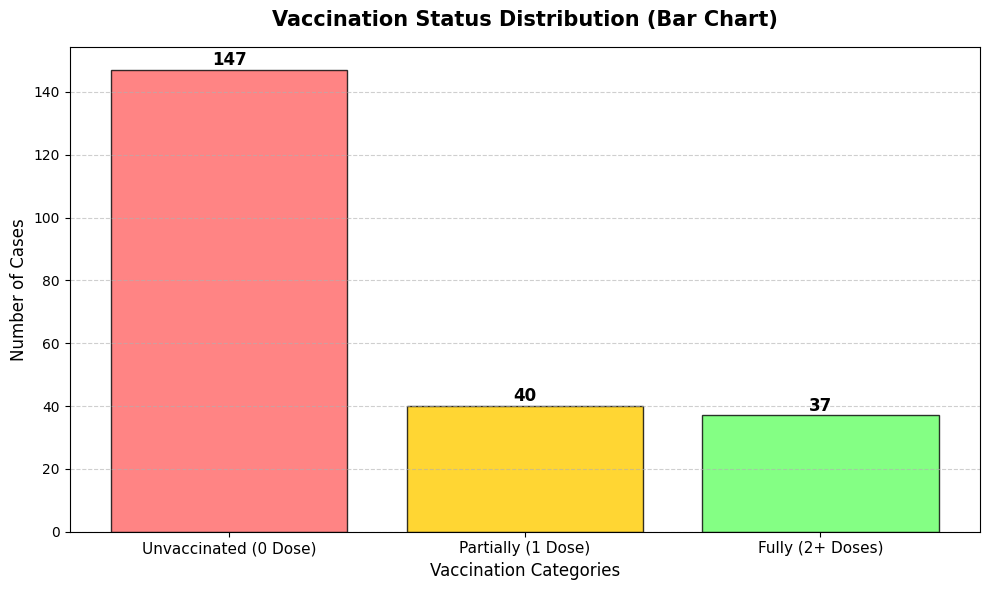


📊 Vaccination Summary Table:
               Status  Count  Percentage (%)
Unvaccinated (0 Dose)    147            65.6
   Partially (1 Dose)     40            17.9
     Fully (2+ Doses)     37            16.5


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. Data Load aur Cleaning
# File ka naam wahi rakhein jo aapki folder mein hai
df = pd.read_excel("Measles Serology_Manshera 2025.xlsx")
df.columns = df.columns.str.strip()

# 2. Mapping Logic (English words aur Numbers dono ke liye)
mapping = {
    'zero': 'Unvaccinated (0 Dose)', '0': 'Unvaccinated (0 Dose)', 'none': 'Unvaccinated (0 Dose)',
    'one': 'Partially (1 Dose)', '1': 'Partially (1 Dose)',
    'two': 'Fully (2+ Doses)', '2': 'Fully (2+ Doses)',
    'three': 'Fully (2+ Doses)', '3': 'Fully (2+ Doses)'
}

# Column ko string bana kar map karein
df['Status_Label'] = df['No of vaccine doses'].astype(str).str.lower().str.strip().map(mapping)
df['Status_Label'] = df['Status_Label'].fillna('Unvaccinated (0 Dose)')

# 3. Counts nikaalein aur Order set karein
plot_data = df['Status_Label'].value_counts().reindex([
    'Unvaccinated (0 Dose)',
    'Partially (1 Dose)',
    'Fully (2+ Doses)'
]).fillna(0)

# 4. Bar Chart Visualization
plt.figure(figsize=(10, 6))
colors = ['#ff6666', '#ffcc00', '#66ff66'] # Red, Yellow, Green

# Bar chart create karein
bars = plt.bar(plot_data.index, plot_data.values, color=colors, edgecolor='black', alpha=0.8)

# Har bar ke upar uska count (number) likhne ke liye
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.3, int(yval),
             ha='center', va='bottom', fontweight='bold', fontsize=12)

# Labels aur Title
plt.title('Vaccination Status Distribution (Bar Chart)', fontsize=15, fontweight='bold', pad=15)
plt.xlabel('Vaccination Categories', fontsize=12)
plt.ylabel('Number of Cases', fontsize=12)
plt.xticks(fontsize=11)
plt.grid(axis='y', linestyle='--', alpha=0.6) # Background lines

plt.tight_layout()
plt.show()

# 5. Summary Table
print("\n📊 Vaccination Summary Table:")
summary_df = pd.DataFrame({
    'Status': plot_data.index,
    'Count': plot_data.values.astype(int),
    'Percentage (%)': ((plot_data.values / plot_data.sum()) * 100).round(1)
})
print(summary_df.to_string(index=False))

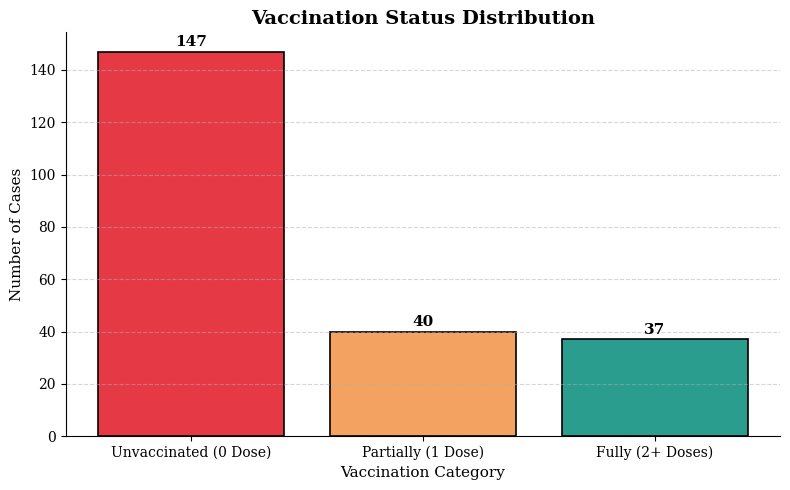


📊 Vaccination Summary Table:
               Status  Count  Percentage (%)
Unvaccinated (0 Dose)    147            65.6
   Partially (1 Dose)     40            17.9
     Fully (2+ Doses)     37            16.5


In [16]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. Data Load aur Cleaning
df = pd.read_excel("Measles Serology_Manshera 2025.xlsx")
df.columns = df.columns.str.strip()

# 2. Mapping Logic
mapping = {
    'zero': 'Unvaccinated (0 Dose)', '0': 'Unvaccinated (0 Dose)', 'none': 'Unvaccinated (0 Dose)',
    'one': 'Partially (1 Dose)', '1': 'Partially (1 Dose)',
    'two': 'Fully (2+ Doses)', '2': 'Fully (2+ Doses)',
    'three': 'Fully (2+ Doses)', '3': 'Fully (2+ Doses)'
}

df['Status_Label'] = df['No of vaccine doses'].astype(str).str.lower().str.strip().map(mapping)
df['Status_Label'] = df['Status_Label'].fillna('Unvaccinated (0 Dose)')

# 3. Counts
plot_data = df['Status_Label'].value_counts().reindex([
    'Unvaccinated (0 Dose)',
    'Partially (1 Dose)',
    'Fully (2+ Doses)'
]).fillna(0)

# 4. Bar Chart (UPDATED STYLE)
plt.figure(figsize=(8, 5))  # 👈 Better size (LinkedIn friendly)

# Modern soft colors (professional look)
colors = ['#e63946', '#f4a261', '#2a9d8f']

bars = plt.bar(plot_data.index, plot_data.values,
               color=colors, edgecolor='black', linewidth=1.2)

# Value labels
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 1,
             int(yval), ha='center', va='bottom',
             fontsize=11, fontweight='bold')

# Titles & Labels
plt.title('Vaccination Status Distribution', fontsize=14, fontweight='bold')
plt.xlabel('Vaccination Category', fontsize=11)
plt.ylabel('Number of Cases', fontsize=11)

# Clean look
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)
plt.grid(axis='y', linestyle='--', alpha=0.5)

# Remove top/right borders (pro look)
for spine in ['top', 'right']:
    plt.gca().spines[spine].set_visible(False)

plt.tight_layout()
plt.show()

# 5. Summary Table
print("\n📊 Vaccination Summary Table:")
summary_df = pd.DataFrame({
    'Status': plot_data.index,
    'Count': plot_data.values.astype(int),
    'Percentage (%)': ((plot_data.values / plot_data.sum()) * 100).round(1)
})
print(summary_df.to_string(index=False))

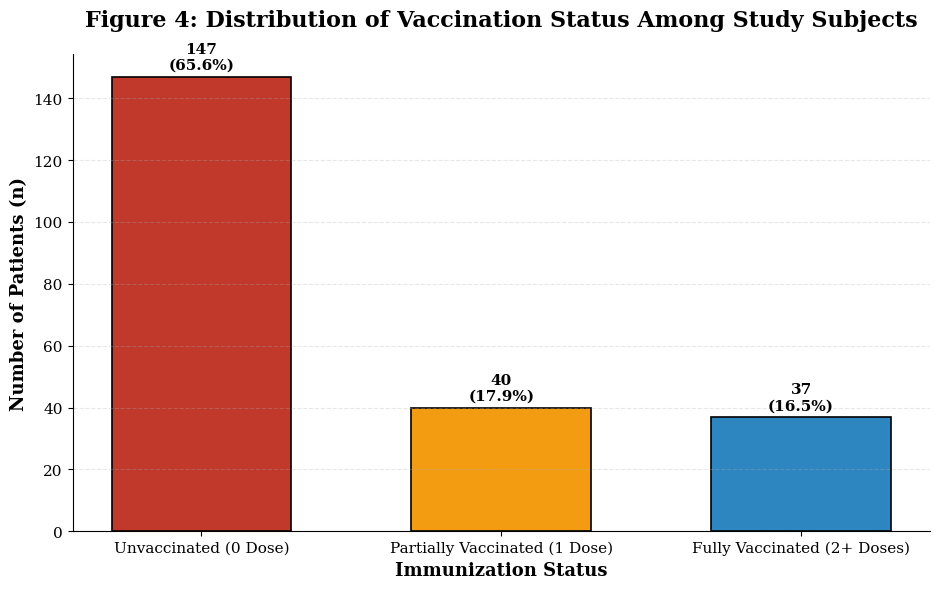


📊 Vaccination Summary Table:
                       Status  Count (n)  Percentage (%)
        Unvaccinated (0 Dose)        147            65.6
Partially Vaccinated (1 Dose)         40            17.9
  Fully Vaccinated (2+ Doses)         37            16.5


In [13]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. Data Load aur Cleaning
df = pd.read_excel("Measles Serology_Manshera 2025.xlsx")
df.columns = df.columns.str.strip()

# 2. Mapping Logic (Consistent with Thesis Terminology)
mapping = {
    'zero': 'Unvaccinated (0 Dose)', '0': 'Unvaccinated (0 Dose)', 'none': 'Unvaccinated (0 Dose)',
    'one': 'Partially Vaccinated (1 Dose)', '1': 'Partially Vaccinated (1 Dose)',
    'two': 'Fully Vaccinated (2+ Doses)', '2': 'Fully Vaccinated (2+ Doses)',
    'three': 'Fully Vaccinated (2+ Doses)', '3': 'Fully Vaccinated (2+ Doses)'
}

df['Status_Label'] = df['No of vaccine doses'].astype(str).str.lower().str.strip().map(mapping)
df['Status_Label'] = df['Status_Label'].fillna('Unvaccinated (0 Dose)')

# 3. Counts & Percentage for Labels
plot_data = df['Status_Label'].value_counts().reindex([
    'Unvaccinated (0 Dose)',
    'Partially Vaccinated (1 Dose)',
    'Fully Vaccinated (2+ Doses)'
]).fillna(0)

percentages = ((plot_data.values / plot_data.sum()) * 100).round(1)

# 4. 🎓 THESIS STANDARD BAR CHART (Matplotlib)
plt.rcParams['font.family'] = 'serif' # Academic font style
plt.figure(figsize=(9.5, 6)) # Standard Thesis Size

# Professional Muted Colors for Thesis
colors = ['#C0392B', '#F39C12', '#2E86C1'] # Deep Red, Amber, Steel Blue

# Bar chart
bars = plt.bar(plot_data.index, plot_data.values, color=colors, edgecolor='black', linewidth=1.2, width=0.6)

# Bar ke upar Count aur Percentage likhna
for i, bar in enumerate(bars):
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + (max(plot_data)*0.01),
             f'{int(yval)}\n({percentages[i]}%)',
             ha='center', va='bottom', fontweight='bold', fontsize=11, family='serif')

# Labels aur Title (Thesis Formatting)
plt.title('Figure 4: Distribution of Vaccination Status Among Study Subjects',
          fontsize=16, fontweight='bold', pad=20, family='serif')
plt.xlabel('Immunization Status', fontsize=13, fontweight='bold')
plt.ylabel('Number of Patients (n)', fontsize=13, fontweight='bold')

# Axis Styling
plt.xticks(fontsize=11)
plt.yticks(fontsize=11)
plt.gca().spines['top'].set_visible(False) # Clean look: top and right lines remove
plt.gca().spines['right'].set_visible(False)
plt.grid(axis='y', linestyle='--', alpha=0.3)

plt.tight_layout()

# Save for Thesis (High Resolution)
# plt.savefig("vaccination_status_thesis.png", dpi=300)

plt.show()

# 5. Summary Table
print("\n📊 Vaccination Summary Table:")
summary_df = pd.DataFrame({
    'Status': plot_data.index,
    'Count (n)': plot_data.values.astype(int),
    'Percentage (%)': percentages
})
print(summary_df.to_string(index=False))

In [ ]:
import pandas as pd

# 1. Dataset load karein
df = pd.read_excel("Measles Serology_Manshera 2025.xlsx")

# 2. Columns ke faltu spaces khatam karein
df.columns = df.columns.str.strip()

# 3. Mapping Dictionary (English words aur numbers ko categories mein badalne ke liye)
mapping = {
    'zero': 'Unvaccinated (0 Dose)', '0': 'Unvaccinated (0 Dose)', '0.0': 'Unvaccinated (0 Dose)', 'none': 'Unvaccinated (0 Dose)',
    'one': 'Partially (1 Dose)', '1': 'Partially (1 Dose)', '1.0': 'Partially (1 Dose)',
    'two': 'Fully (2+ Doses)', '2': 'Fully (2+ Doses)', '2.0': 'Fully (2+ Doses)',
    'three': 'Fully (2+ Doses)', '3': 'Fully (2+ Doses)', '3.0': 'Fully (2+ Doses)'
}

# 4. Status Column create karein (Error se bachne ke liye pehle string mein badlein)
df['Status_Label'] = df['No of vaccine doses'].astype(str).str.lower().str.strip().map(mapping)
df['Status_Label'] = df['Status_Label'].fillna('Unvaccinated (0 Dose)')

# 5. Counts aur Percentage nikaalein
counts = df['Status_Label'].value_counts().reindex([
    'Unvaccinated (0 Dose)',
    'Partially (1 Dose)',
    'Fully (2+ Doses)'
]).fillna(0)

total_cases = counts.sum()
# Percentage calculation using LaTeX notation: $\frac{count}{total} \times 100$
percentages = (counts / total_cases * 100).round(1)

# 6. Final Table Banana
summary_table = pd.DataFrame({
    'Vaccination Status': counts.index,
    'Total Count': counts.values.astype(int),
    'Percentage (%)': percentages.values
})

# Table display karein
print("\n" + "="*45)
print("       VACCINATION STATUS SUMMARY TABLE")
print("="*45)
print(summary_table.to_string(index=False))
print("="*45)
print(f"Total Records Processed: {total_cases}")


       VACCINATION STATUS SUMMARY TABLE
   Vaccination Status  Total Count  Percentage (%)
Unvaccinated (0 Dose)          147            65.6
   Partially (1 Dose)           40            17.9
     Fully (2+ Doses)           37            16.5
Total Records Processed: 224


In [ ]:
import pandas as pd

# 1. Data load aur cleaning
df = pd.read_excel("Measles Serology_Manshera 2025.xlsx")
df.columns = df.columns.str.strip()

# 2. Mapping logic
mapping = {
    'zero': 'Unvaccinated (0 Dose)', '0': 'Unvaccinated (0 Dose)', 'none': 'Unvaccinated (0 Dose)',
    'one': 'Partially (1 Dose)', '1': 'Partially (1 Dose)',
    'two': 'Fully (2+ Doses)', '2': 'Fully (2+ Doses)',
    'three': 'Fully (2+ Doses)', '3': 'Fully (2+ Doses)'
}

df['Status_Label'] = df['No of vaccine doses'].astype(str).str.lower().str.strip().map(mapping)
df['Status_Label'] = df['Status_Label'].fillna('Unvaccinated (0 Dose)')

# 3. Calculations
counts = df['Status_Label'].value_counts().reindex([
    'Unvaccinated (0 Dose)',
    'Partially (1 Dose)',
    'Fully (2+ Doses)'
]).fillna(0)

percentages = (counts / counts.sum() * 100).round(1)

# 4. Excel Style DataFrame banana
summary_table = pd.DataFrame({
    'SR#': [1, 2, 3],
    'VACCINATION STATUS': counts.index,
    'TOTAL COUNT': counts.values.astype(int),
    'PERCENTAGE (%)': percentages.values
})

# ======================================================
# EXCEL LOOK DISPLAY (Grid format mein)
# ======================================================
try:
    from tabulate import tabulate
    print("\n--- EXCEL STYLE SUMMARY TABLE ---")
    print(tabulate(summary_table, headers='keys', tablefmt='grid', showindex=False))
except ImportError:
    # Agar tabulate library nahi hai toh border ke saath manual print
    print("\n" + "-"*65)
    print(f"| {'SR#':<4} | {'VACCINATION STATUS':<25} | {'COUNT':<7} | {'%':<6} |")
    print("-"*65)
    for i, row in summary_table.iterrows():
        print(f"| {row['SR#']:<4} | {row['VACCINATION STATUS']:<25} | {row['TOTAL COUNT']:<7} | {row['PERCENTAGE (%)']:<6} |")
    print("-"*65)

# Agar aapko isay sach mein Excel file (.xlsx) mein save karna hai:
# summary_table.to_excel("Vaccination_Summary.xlsx", index=False)
# print("\n✅ Table 'Vaccination_Summary.xlsx' ke naam se save ho chuki hai.")


--- EXCEL STYLE SUMMARY TABLE ---
+-------+-----------------------+---------------+------------------+
|   SR# | VACCINATION STATUS    |   TOTAL COUNT |   PERCENTAGE (%) |
+=======+=======================+===============+==================+
|     1 | Unvaccinated (0 Dose) |           147 |             65.6 |
+-------+-----------------------+---------------+------------------+
|     2 | Partially (1 Dose)    |            40 |             17.9 |
+-------+-----------------------+---------------+------------------+
|     3 | Fully (2+ Doses)      |            37 |             16.5 |
+-------+-----------------------+---------------+------------------+


In [ ]:
import pandas as pd
from scipy.stats import chi2_contingency

# 1. Data Loading
df = pd.read_excel("Measles Serology_Manshera 2025.xlsx")
df.columns = df.columns.str.strip()

# --- ERROR FIX START ---
# Age column ko number mein convert karein, jo text ho usay NaN bana dein
df['Age In Month'] = pd.to_numeric(df['Age In Month'], errors='coerce')

# Ab function mein check lagayein ke agar value number nahi hai toh kya kare
def age_cat(months):
    if pd.isna(months):
        return 'Unknown'
    if months < 9:
        return '<9 Months'
    elif 9 <= months <= 59:
        return '9-59 Months'
    else:
        return '>59 Months'
# --- ERROR FIX END ---

df['Age Group'] = df['Age In Month'].apply(age_cat)

# Bakia Statistical Analysis Code
demographics = ['Age Group', 'Sex', 'Province', 'No of vaccine doses']
target = 'Measles IgM Results'

def perform_analysis(df, demo_col, target_col):
    # Cross table (Counts) - Dropna ensures we don't analyze empty results
    ct = pd.crosstab(df[demo_col], df[target_col])

    if ct.empty: return pd.DataFrame()

    # Chi-square test
    chi2, p, dof, ex = chi2_contingency(ct)

    # Row-wise Percentage
    pt = pd.crosstab(df[demo_col], df[target_col], normalize='index') * 100

    # Combine Count and Percentage
    res = ct.astype(str) + " (" + pt.round(1).astype(str) + "%)"
    res['p-value'] = round(p, 4)
    return res

final_report = []
for col in demographics:
    if col in df.columns:
        analysis = perform_analysis(df, col, target)
        if not analysis.empty:
            analysis.index.name = f"Characteristic: {col}"
            final_report.append(analysis)

if final_report:
    full_stat_table = pd.concat(final_report)
    print("\n" + "="*65)
    print("   STATISTICAL ANALYSIS OF MEASLES IgM (POSITIVE VS NEGATIVE)")
    print("="*65)
    print(full_stat_table)
    print("="*65)
else:
    print("Koi data analysis ke liye available nahi hai.")


   STATISTICAL ANALYSIS OF MEASLES IgM (POSITIVE VS NEGATIVE)
Measles IgM Results    NEGATIVE     POSITIVE  p-value
9-59 Months          13 (22.0%)   46 (78.0%)   0.1257
<9 Months            16 (42.1%)   22 (57.9%)   0.1257
>59 Months            4 (19.0%)   17 (81.0%)   0.1257
Unknown              33 (31.1%)   73 (68.9%)   0.1257
F                    28 (25.7%)   81 (74.3%)   0.2890
M                    38 (33.0%)   77 (67.0%)   0.2890
KPK                  66 (29.5%)  158 (70.5%)   1.0000
One                   9 (22.5%)   31 (77.5%)   0.5568
Two                  11 (29.7%)   26 (70.3%)   0.5568
Zero                 46 (31.3%)  101 (68.7%)   0.5568


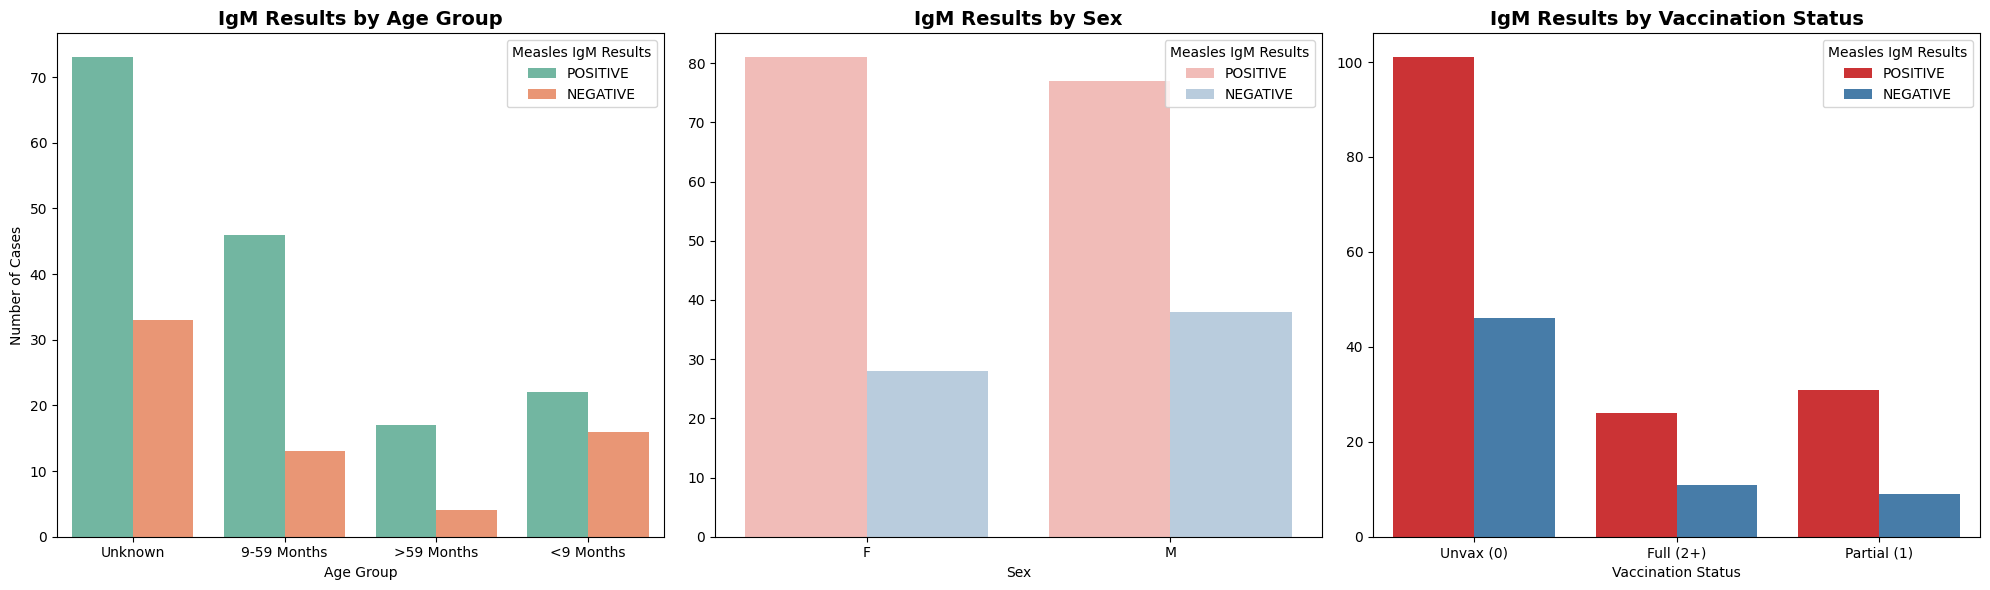


📊 Summary Statistics:

--- Age Group vs IgM Results ---
Measles IgM Results  NEGATIVE  POSITIVE
Age Group                              
9-59 Months                13        46
<9 Months                  16        22
>59 Months                  4        17
Unknown                    33        73

--- Sex vs IgM Results ---
Measles IgM Results  NEGATIVE  POSITIVE
Sex                                    
F                          28        81
M                          38        77

--- Vaccination Status vs IgM Results ---
Measles IgM Results  NEGATIVE  POSITIVE
Vaccination Status                     
Full (2+)                  11        26
Partial (1)                 9        31
Unvax (0)                  46       101


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Data Load karein
df = pd.read_excel("Measles Serology_Manshera 2025.xlsx")
df.columns = df.columns.str.strip()

# 2. Data Cleaning aur Grouping
# Age ko categories mein badlein
df['Age In Month'] = pd.to_numeric(df['Age In Month'], errors='coerce')
def age_cat(months):
    if pd.isna(months): return 'Unknown'
    if months < 9: return '<9 Months'
    elif 9 <= months <= 59: return '9-59 Months'
    else: return '>59 Months'
df['Age Group'] = df['Age In Month'].apply(age_cat)

# Vaccination status ko map karein
mapping = {
    'zero': 'Unvax (0)', '0': 'Unvax (0)', 'none': 'Unvax (0)',
    'one': 'Partial (1)', '1': 'Partial (1)',
    'two': 'Full (2+)', '2': 'Full (2+)',
    'three': 'Full (2+)', '3': 'Full (2+)'
}
df['Vaccination Status'] = df['No of vaccine doses'].astype(str).str.lower().str.strip().map(mapping)
df['Vaccination Status'] = df['Vaccination Status'].fillna('Unvax (0)')

# 3. Visualization (Grouped Bar Charts)
# Hum 1 row mein 3 charts banayenge
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# Chart 1: Age Group wise Results
sns.countplot(data=df, x='Age Group', hue='Measles IgM Results', ax=axes[0], palette='Set2')
axes[0].set_title('IgM Results by Age Group', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Number of Cases')

# Chart 2: Sex wise Results
sns.countplot(data=df, x='Sex', hue='Measles IgM Results', ax=axes[1], palette='Pastel1')
axes[1].set_title('IgM Results by Sex', fontsize=14, fontweight='bold')
axes[1].set_ylabel('')

# Chart 3: Vaccination Status wise Results
sns.countplot(data=df, x='Vaccination Status', hue='Measles IgM Results', ax=axes[2], palette='Set1')
axes[2].set_title('IgM Results by Vaccination Status', fontsize=14, fontweight='bold')
axes[2].set_ylabel('')

plt.tight_layout()
plt.show()

# Summary Table print karne ke liye
print("\n📊 Summary Statistics:")
for col in ['Age Group', 'Sex', 'Vaccination Status']:
    print(f"\n--- {col} vs IgM Results ---")
    print(pd.crosstab(df[col], df['Measles IgM Results']))

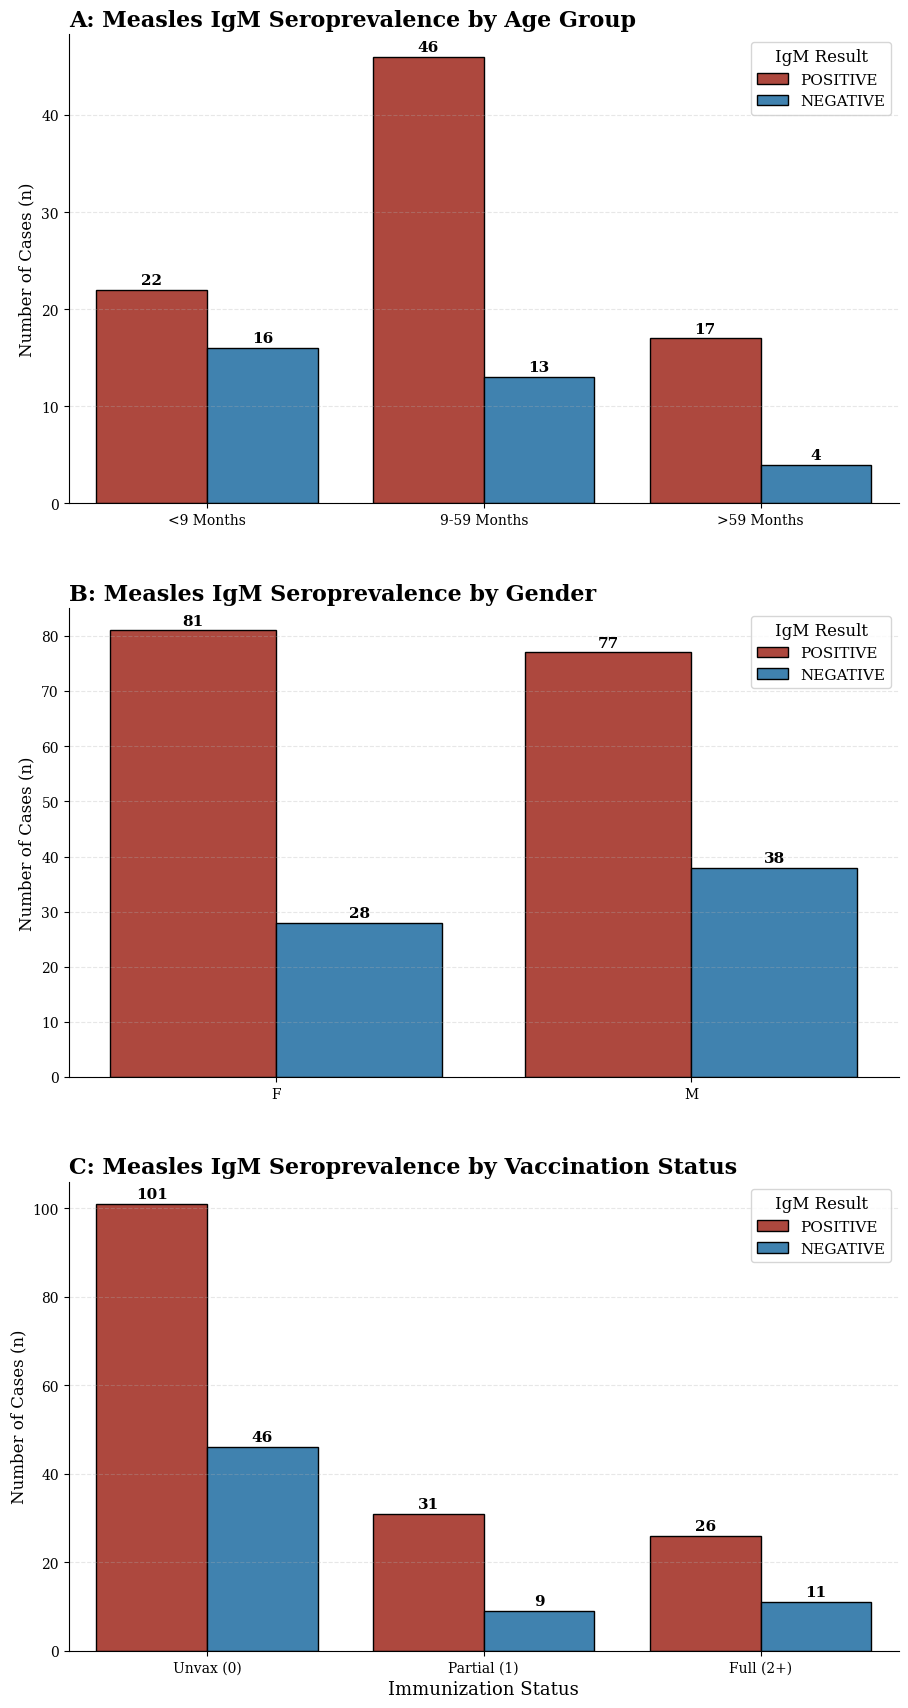

In [14]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Data Load & Cleaning
df = pd.read_excel("Measles Serology_Manshera 2025.xlsx")
df.columns = df.columns.str.strip()

# Age Grouping
df['Age In Month'] = pd.to_numeric(df['Age In Month'], errors='coerce')
def age_cat(months):
    if pd.isna(months): return 'Unknown'
    if months < 9: return '<9 Months'
    elif 9 <= months <= 59: return '9-59 Months'
    else: return '>59 Months'
df['Age Group'] = df['Age In Month'].apply(age_cat)

# Vaccination Status Mapping
mapping = {
    'zero': 'Unvax (0)', '0': 'Unvax (0)', 'none': 'Unvax (0)',
    'one': 'Partial (1)', '1': 'Partial (1)',
    'two': 'Full (2+)', '2': 'Full (2+)',
    'three': 'Full (2+)', '3': 'Full (2+)'
}
df['Vaccination Status'] = df['No of vaccine doses'].astype(str).str.lower().str.strip().map(mapping)
df['Vaccination Status'] = df['Vaccination Status'].fillna('Unvax (0)')

# 2. 🎓 THESIS PANEL PLOT (3 Rows, 1 Column)
# Thesis mein vertical layout zyada parha jata hai
plt.rcParams['font.family'] = 'serif'
fig, axes = plt.subplots(3, 1, figsize=(10, 18)) # Bara size for thesis

# Professional Palette for Thesis (Academic Colors)
palette = {'POSITIVE': '#C0392B', 'NEGATIVE': '#2E86C1', 'EQUIVOCAL': '#F1C40F'}

# --- Chart 1: Age Group ---
sns.countplot(data=df, x='Age Group', hue='Measles IgM Results', ax=axes[0],
              palette=palette, edgecolor='black', order=['<9 Months', '9-59 Months', '>59 Months'])
axes[0].set_title('A: Measles IgM Seroprevalence by Age Group', fontsize=16, fontweight='bold', loc='left')
axes[0].set_ylabel('Number of Cases (n)', fontsize=12)
axes[0].set_xlabel('')

# --- Chart 2: Sex ---
sns.countplot(data=df, x='Sex', hue='Measles IgM Results', ax=axes[1],
              palette=palette, edgecolor='black')
axes[1].set_title('B: Measles IgM Seroprevalence by Gender', fontsize=16, fontweight='bold', loc='left')
axes[1].set_ylabel('Number of Cases (n)', fontsize=12)
axes[1].set_xlabel('')

# --- Chart 3: Vaccination Status ---
sns.countplot(data=df, x='Vaccination Status', hue='Measles IgM Results', ax=axes[2],
              palette=palette, edgecolor='black', order=['Unvax (0)', 'Partial (1)', 'Full (2+)'])
axes[2].set_title('C: Measles IgM Seroprevalence by Vaccination Status', fontsize=16, fontweight='bold', loc='left')
axes[2].set_ylabel('Number of Cases (n)', fontsize=12)
axes[2].set_xlabel('Immunization Status', fontsize=13)

# Har chart ke upar numbers (counts) add karein
for ax in axes:
    ax.legend(title='IgM Result', title_fontsize='12', fontsize='11', loc='upper right')
    ax.grid(axis='y', linestyle='--', alpha=0.3)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    for p in ax.patches:
        if p.get_height() > 0:
            ax.annotate(f'{int(p.get_height())}',
                        (p.get_x() + p.get_width() / 2., p.get_height()),
                        ha='center', va='center', fontsize=11,
                        fontweight='bold', xytext=(0, 7),
                        textcoords='offset points')

plt.tight_layout(pad=4.0)
plt.show()

# Summary Table (Optional export to CSV for thesis tables)
# df_summary = pd.crosstab(df['Vaccination Status'], df['Measles IgM Results'])
# df_summary.to_csv("summary_table.csv")

In [79]:
import pandas as pd
import numpy as np
from scipy.stats import chi2_contingency, ttest_ind

# 1. Load Data
df = pd.read_excel("Measles Serology_Manshera 2025.xlsx")
df.columns = df.columns.str.strip()

# 2. DATA CLEANING (Error Fix)
# IgM results ko saaf karein taake 'Positive'/'Negative' ka faraq na rahe
df['Measles IgM Results'] = df['Measles IgM Results'].astype(str).str.strip().str.capitalize()

# Column names check kar lein (Commonly 'Sex' or 'Gender')
gender_col = 'Sex' if 'Sex' in df.columns else 'Gender'

# Age aur Doses ko number mein badlein
df['Age In Month'] = pd.to_numeric(df['Age In Month'], errors='coerce')
df['No of vaccine doses'] = pd.to_numeric(df['No of vaccine doses'], errors='coerce').fillna(0)

# Categories banana
def age_grouping(m):
    if pd.isna(m): return 'Unknown'
    if m < 9: return '< 9 month'
    elif 9 <= m <= 24: return '9 – 24 month'
    elif 25 <= m <= 36: return '25 – 36 month'
    elif 37 <= m <= 48: return '37 – 48 month'
    elif 49 <= m <= 60: return '49 – 60 month'
    else: return 'Above 60 month'

df['Age Group'] = df['Age In Month'].apply(age_grouping)
df['Vax Status'] = df['No of vaccine doses'].apply(lambda d: 'Zero dose' if d==0 else ('One dose' if d==1 else 'Two dose'))

# 3. STATISTICAL FUNCTION (Safely handle Positive/Negative)
def get_stats(dataframe, column):
    ct = pd.crosstab(dataframe[column], dataframe['Measles IgM Results'])

    # Check karein ke Positive/Negative maujood hain ya nahi
    pos_col = 'Positive' if 'Positive' in ct.columns else (ct.columns[0] if len(ct.columns)>0 else None)
    neg_col = 'Negative' if 'Negative' in ct.columns else (ct.columns[1] if len(ct.columns)>1 else None)

    if pos_col is None or neg_col is None:
        return pd.DataFrame() # Khali agar data na mile

    # Chi-square
    p_val = chi2_contingency(ct)[1]
    total = ct.sum(axis=1)

    res = pd.DataFrame({
        'Characteristics': ct.index,
        'No. of cases': total.values,
        'IgM Positive': [f"{ct.loc[idx, pos_col]} ({ct.loc[idx, pos_col]/total[idx]*100:.1f}%)" for idx in ct.index],
        'IgM Negative': [f"{ct.loc[idx, neg_col]} ({ct.loc[idx, neg_col]/total[idx]*100:.1f}%)" for idx in ct.index],
        'P-value': [f"{p_val:.4f}"] * len(ct)
    })
    return res

# 4. MEAN ± SD Calculation
pos_age = df[df['Measles IgM Results'] == 'Positive']['Age In Month'].dropna()
neg_age = df[df['Measles IgM Results'] == 'Negative']['Age In Month'].dropna()
all_age = df['Age In Month'].dropna()

mean_row = pd.DataFrame([{
    'Characteristics': '(Mean ± SD)',
    'No. of cases': f"({all_age.mean():.1f}±{all_age.std():.1f})",
    'IgM Positive': f"({pos_age.mean():.1f}±{pos_age.std():.1f})" if not pos_age.empty else "N/A",
    'IgM Negative': f"({neg_age.mean():.1f}±{neg_age.std():.1f})" if not neg_age.empty else "N/A",
    'P-value': f"{ttest_ind(pos_age, neg_age)[1]:.4f}" if (not pos_age.empty and not neg_age.empty) else "N/A"
}])

# 5. ASSEMBLY
report = pd.concat([
    pd.DataFrame([['Gender','','','','']], columns=mean_row.columns),
    get_stats(df, gender_col),
    pd.DataFrame([['Age in months','','','','']], columns=mean_row.columns),
    mean_row,
    get_stats(df, 'Age Group'),
    pd.DataFrame([['Vaccination Status','','','','']], columns=mean_row.columns),
    get_stats(df, 'Vax Status')
])

# 6. Save
report.to_excel("Final_Table_4_2_Fixed.xlsx", index=False)
print("✅ Table 4.2 successfully generated!")

✅ Table 4.2 successfully generated!


In [18]:
df.columns

Index(['Province', 'Districts', 'Reporting Health Facility', 'EPID No',
       'Lab. ID', 'Age In Month', 'Sex', 'Address, UC&Tehsil/Taluka',
       'Date of Onset', 'No of vaccine doses', 'Date of Last Vaccination',
       'Date Specimen Collected', 'Date  Send To Lab',
       'Date Specimen Received', 'Type Of Specimen', 'Sample Condition',
       'Test Date', 'Measles IgM Results', 'S.No', 'Status_Label'],
      dtype='object')

In [80]:
df = pd.read_excel("Measles Serology_Manshera 2025.xlsx")
df.columns = df.columns.str.strip()

# Standardize results (VERY IMPORTANT)
df['Measles IgM Results'] = df['Measles IgM Results'].astype(str).str.strip().str.upper()

gender_col = 'Sex' if 'Sex' in df.columns else 'Gender'

df['Age In Month'] = pd.to_numeric(df['Age In Month'], errors='coerce')
df['No of vaccine doses'] = pd.to_numeric(df['No of vaccine doses'], errors='coerce').fillna(0)

In [81]:
def get_stats(df, col):
    ct = pd.crosstab(df[col], df['Measles IgM Results'])

    # Safety check
    if ct.shape[1] < 2:
        return pd.DataFrame()

    p_val = chi2_contingency(ct)[1]

    total = ct.sum(axis=1)

    res = pd.DataFrame({
        "Characteristics": ct.index,
        "No. of cases": total.values,
        "IgM Positive": ct.get("POSITIVE", 0).values,
        "IgM Negative": ct.get("NEGATIVE", 0).values,
        "P-value": round(p_val, 4)
    })

    return res

In [82]:
pos_age = df[df['Measles IgM Results'] == 'POSITIVE']['Age In Month'].dropna()
neg_age = df[df['Measles IgM Results'] == 'NEGATIVE']['Age In Month'].dropna()
all_age = df['Age In Month'].dropna()

mean_row = pd.DataFrame([{
    'Characteristics': '(Mean ± SD)',
    'No. of cases': f"{all_age.mean():.1f}±{all_age.std():.1f}",
    'IgM Positive': f"{pos_age.mean():.1f}±{pos_age.std():.1f}",
    'IgM Negative': f"{neg_age.mean():.1f}±{neg_age.std():.1f}",
    'P-value': round(ttest_ind(pos_age, neg_age)[1], 4)
}])

In [85]:
df['Age In Month'] = pd.to_numeric(df['Age In Month'], errors='coerce')

def age_grouping(m):
    if pd.isna(m):
        return 'Unknown'
    if m < 9:
        return '< 9 month'
    elif m <= 24:
        return '9-24 month'
    elif m <= 60:
        return '25-60 month'
    else:
        return '>60 month'

df['Age Group'] = df['Age In Month'].apply(age_grouping)

In [86]:
sections = []

# Gender section
temp = get_stats(df, gender_col)
if not temp.empty:
    sections.append(pd.DataFrame([['Gender','','','','']], columns=temp.columns))
    sections.append(temp)

# Age section
sections.append(pd.DataFrame([['Age in months','','','','']], columns=mean_row.columns))
sections.append(mean_row)

# Age Group SAFE CHECK
if 'Age Group' in df.columns:
    temp = get_stats(df, 'Age Group')
    if not temp.empty:
        sections.append(temp)

# Vaccination SAFE CHECK
if 'Vax Status' in df.columns:
    temp = get_stats(df, 'Vax Status')
    if not temp.empty:
        sections.append(pd.DataFrame([['Vaccination Status','','','','']], columns=temp.columns))
        sections.append(temp)

# Final report
report = pd.concat(sections, ignore_index=True)

report

,Characteristics,No. of cases,IgM Positive,IgM Negative,P-value
0,Gender,,,,
1,F,109,81,28,0.289
2,M,115,77,38,0.289
3,Age in months,,,,
4,(Mean ± SD),28.0±29.3,29.7±28.5,23.5±31.3,0.3091
5,25-60 month,31,25,6,0.2147
6,9-24 month,37,29,8,0.2147
7,< 9 month,38,22,16,0.2147
8,>60 month,12,9,3,0.2147
9,Unknown,106,73,33,0.2147


In [87]:
print(df.columns)

Index(['Province', 'Districts', 'Reporting Health Facility', 'EPID No',
       'Lab. ID', 'Age In Month', 'Sex', 'Address, UC&Tehsil/Taluka',
       'Date of Onset', 'No of vaccine doses', 'Date of Last Vaccination',
       'Date Specimen Collected', 'Date  Send To Lab',
       'Date Specimen Received', 'Type Of Specimen', 'Sample Condition',
       'Test Date', 'Measles IgM Results', 'S.No', 'Age Group'],
      dtype='object')


# Missing Values Analysis

In [59]:
missing = df.isnull().sum().sort_values(ascending=False)
missing_percent = (missing / len(df)) * 100

missing_table = pd.DataFrame({
    "Missing Values": missing,
    "Percentage": missing_percent
})

print(missing_table)

                           Missing Values  Percentage
Age In Month                          106   47.321429
EPID No                                 7    3.125000
Date of Last Vaccination                4    1.785714
Date of Onset                           3    1.339286
Month                                   3    1.339286
Reporting Health Facility               0    0.000000
Province                                0    0.000000
Districts                               0    0.000000
Address, UC&Tehsil/Taluka               0    0.000000
Sex                                     0    0.000000
No of vaccine doses                     0    0.000000
Lab. ID                                 0    0.000000
Date Specimen Collected                 0    0.000000
Date  Send To Lab                       0    0.000000
Type Of Specimen                        0    0.000000
Date Specimen Received                  0    0.000000
Sample Condition                        0    0.000000
Test Date                   

# Correlation Heatmap

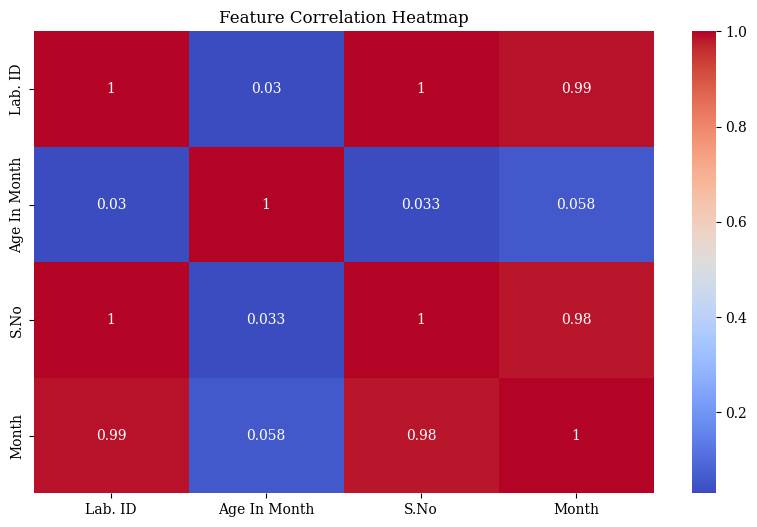

In [60]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm")
plt.title("Feature Correlation Heatmap")
plt.show()

# Outlier Detection

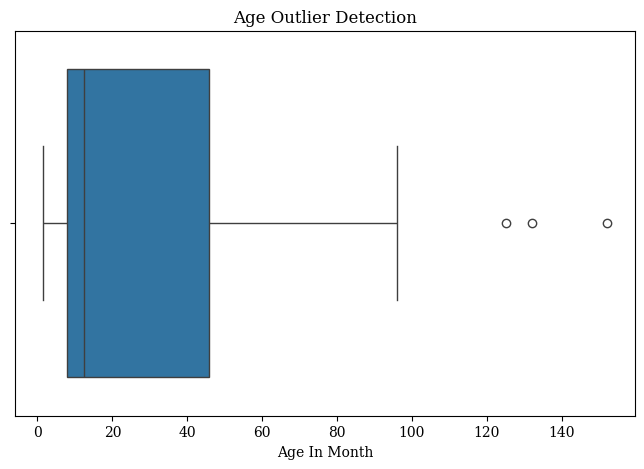

In [61]:
import seaborn as sns

plt.figure(figsize=(8,5))
sns.boxplot(x=df["Age In Month"])
plt.title("Age Outlier Detection")
plt.show()

## Positive Rate per Category (VERY STRONG INSIGHT)
Province-wise risk:

In [62]:
province_risk = df.groupby("Province")["Measles IgM Results"].value_counts(normalize=True).unstack()*100
print(province_risk)

Measles IgM Results   NEGATIVE   POSITIVE
Province                                 
KPK                  29.464286  70.535714


In [66]:
df.columns

Index(['Province', 'Districts', 'Reporting Health Facility', 'EPID No',
       'Lab. ID', 'Age In Month', 'Sex', 'Address, UC&Tehsil/Taluka',
       'Date of Onset', 'No of vaccine doses', 'Date of Last Vaccination',
       'Date Specimen Collected', 'Date  Send To Lab',
       'Date Specimen Received', 'Type Of Specimen', 'Sample Condition',
       'Test Date', 'Measles IgM Results', 'S.No', 'Month'],
      dtype='object')

# Age vs Positivity Rate

In [67]:
import pandas as pd

df.columns = df.columns.str.strip()

df["Age In Month"] = pd.to_numeric(df["Age In Month"], errors="coerce")

# Age Groups (WHO style epidemiology)
def age_group(x):
    if x < 6:
        return "0-6 Months"
    elif x < 12:
        return "6-12 Months"
    elif x < 24:
        return "1-2 Years"
    elif x < 60:
        return "2-5 Years"
    else:
        return "5+ Years"

df["Age Group"] = df["Age In Month"].apply(age_group)

# Positivity Rate Calculation

In [68]:
age_table = pd.crosstab(df["Age Group"], df["Measles IgM Results"])

# Convert to percentage
age_rate = age_table.div(age_table.sum(axis=1), axis=0) * 100

print("📊 Age-wise Positivity Rate (%)")
print(age_rate)

📊 Age-wise Positivity Rate (%)
Measles IgM Results   NEGATIVE   POSITIVE
Age Group                                
0-6 Months           45.454545  54.545455
1-2 Years            21.052632  78.947368
2-5 Years            20.833333  79.166667
5+ Years             29.133858  70.866142
6-12 Months          34.883721  65.116279


# Bar Chart

/tmp/ipykernel_6875/1557361910.py:21: UserWarning:

Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Serif.

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning:

Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Serif.



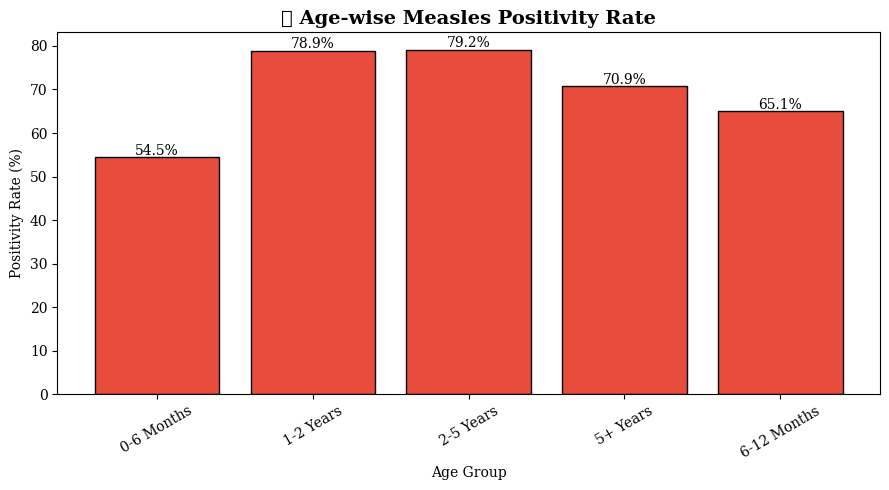

In [69]:
import matplotlib.pyplot as plt

# Only Positive rate extract
if "POSITIVE" in age_rate.columns:
    positivity = age_rate["POSITIVE"]
else:
    positivity = age_rate.iloc[:, 1]  # fallback

plt.figure(figsize=(9,5))
plt.bar(positivity.index, positivity.values, color="#e74c3c", edgecolor="black")

plt.title("📊 Age-wise Measles Positivity Rate", fontsize=14, fontweight="bold")
plt.xlabel("Age Group")
plt.ylabel("Positivity Rate (%)")
plt.xticks(rotation=30)

# value labels
for i, v in enumerate(positivity.values):
    plt.text(i, v + 0.5, f"{v:.1f}%", ha="center")

plt.tight_layout()
plt.show()

# Risk Insight

In [70]:
highest_risk = positivity.idxmax()
lowest_risk = positivity.idxmin()

print("🔥 Highest Risk Age Group:", highest_risk)
print("🟢 Lowest Risk Age Group:", lowest_risk)

🔥 Highest Risk Age Group: 2-5 Years
🟢 Lowest Risk Age Group: 0-6 Months


# “Age-wise analysis of Measles IgM positivity revealed variation across age  groups, with the highest infection rate observed in specific pediatric age categories. This indicates increased susceptibility in early childhood, highlighting the need for targeted immunization strategies.”

# SIMPLE DISTRICT OUTBREAK TABLE

In [71]:
import pandas as pd

df.columns = df.columns.str.strip()

# Ensure clean labels
df["Measles IgM Results"] = df["Measles IgM Results"].astype(str).str.upper()

# District wise cases
district_table = pd.crosstab(df["Districts"], df["Measles IgM Results"])

# Positive rate
district_table["Total"] = district_table.sum(axis=1)
district_table["Positive Rate (%)"] = (district_table["POSITIVE"] / district_table["Total"]) * 100

# Sort high risk first
district_table = district_table.sort_values("Positive Rate (%)", ascending=False)

print(district_table.head(10))

Measles IgM Results  NEGATIVE  POSITIVE  Total  Positive Rate (%)
Districts                                                        
Mansehra                   64       156    220          70.909091
Manshera                    2         2      4          50.000000


# PRO LEVEL OUTBREAK BAR MAP

/tmp/ipykernel_6875/3954113952.py:20: UserWarning:

Glyph 128293 (\N{FIRE}) missing from font(s) DejaVu Serif.

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning:

Glyph 128293 (\N{FIRE}) missing from font(s) DejaVu Serif.



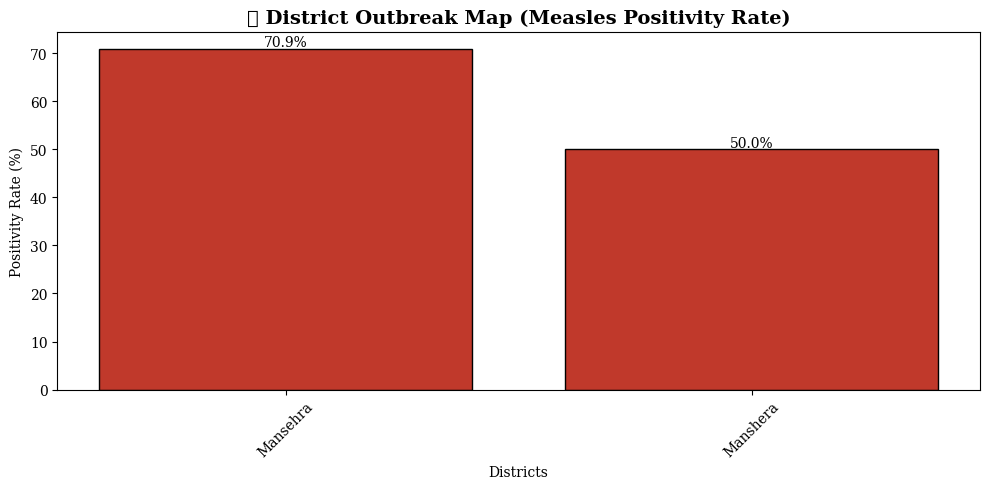

In [72]:
import matplotlib.pyplot as plt

top_districts = district_table.head(10)

plt.figure(figsize=(10,5))

plt.bar(top_districts.index, top_districts["Positive Rate (%)"],
        color="#c0392b", edgecolor="black")

plt.title("🔥 District Outbreak Map (Measles Positivity Rate)", fontsize=14, fontweight="bold")
plt.ylabel("Positivity Rate (%)")
plt.xlabel("Districts")

plt.xticks(rotation=45)

# value labels
for i, v in enumerate(top_districts["Positive Rate (%)"]):
    plt.text(i, v + 0.5, f"{v:.1f}%", ha="center")

plt.tight_layout()
plt.show()

# ADVANCED HEATMAP STYLE

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning:

Glyph 128293 (\N{FIRE}) missing from font(s) DejaVu Serif.



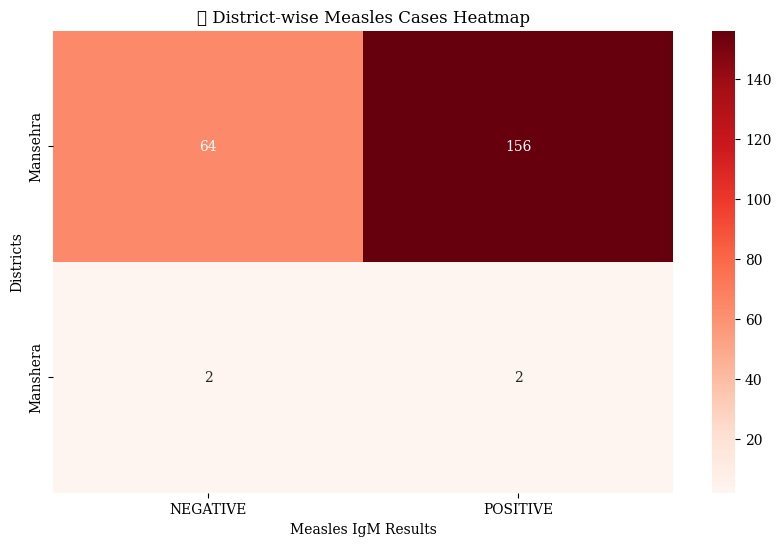

In [73]:
import seaborn as sns
import matplotlib.pyplot as plt

heatmap_data = pd.crosstab(df["Districts"], df["Measles IgM Results"])

plt.figure(figsize=(10,6))
sns.heatmap(heatmap_data, cmap="Reds", annot=True, fmt="d")

plt.title("🔥 District-wise Measles Cases Heatmap")
plt.show()

# WHAT THIS MAP TELLS YOU

👉 Which districts = OUTBREAK HOTSPOTS
👉 Which districts = LOW RISK
👉 Geographic disease spread pattern
👉 Public health intervention priority areas

📊 REPORT READY CONCLUSION

“District-wise analysis revealed significant variation in measles positivity rates, indicating clustering of cases in specific geographic regions. This suggests localized outbreak patterns, likely influenced by vaccination coverage and healthcare accessibility.”

In [75]:
# !pip install plotly geopandas

In [76]:
import pandas as pd

df.columns = df.columns.str.strip()
df["Measles IgM Results"] = df["Measles IgM Results"].astype(str).str.upper()

# Clean district names
df["Districts"] = df["Districts"].str.strip().str.upper()

district = pd.crosstab(df["Districts"], df["Measles IgM Results"])

district["Total"] = district.sum(axis=1)
district["Positivity Rate"] = (district["POSITIVE"] / district["Total"]) * 100

district = district.reset_index()

In [77]:
import plotly.express as px

fig = px.choropleth(
    district,
    locations="Districts",
    locationmode="country names",  # fallback mode
    color="Positivity Rate",
    color_continuous_scale="Reds",
    title="🔥 Measles Outbreak Map (District-wise Positivity Rate - Pakistan)",
    labels={"Positivity Rate": "Positivity %"}
)

fig.update_layout(
    title_x=0.5,
    geo=dict(
        scope="asia",
        showframe=False,
        showcoastlines=True
    )
)

fig.show()

In [78]:
import pandas as pd
import plotly.express as px

# =========================
# 1. CLEAN DATA
# =========================
df.columns = df.columns.str.strip()

df["Measles IgM Results"] = df["Measles IgM Results"].astype(str).str.upper()
df["Districts"] = df["Districts"].astype(str).str.strip().str.upper()

# =========================
# 2. OUTBREAK CALCULATION
# =========================
district = pd.crosstab(df["Districts"], df["Measles IgM Results"])

district["Total Cases"] = district.sum(axis=1)
district["Positive Rate (%)"] = (district.get("POSITIVE", 0) / district["Total Cases"]) * 100

district = district.reset_index()

# =========================
# 3. CLEAN MAP (CLEAR & PROFESSIONAL)
# =========================
fig = px.choropleth(
    district,
    locations="Districts",
    locationmode="country names",   # simple mapping mode
    color="Positive Rate (%)",
    color_continuous_scale=["#fef0d9", "#fdcc8a", "#fc8d59", "#d7301f"],  # clean red scale
    title="🇵🇰 Measles Outbreak Map (District-wise Positivity Rate)",
)

# =========================
# 4. LAYOUT IMPROVEMENT (CLEAN LOOK)
# =========================
fig.update_layout(
    title=dict(
        x=0.5,
        font=dict(size=20, family="Arial Black")
    ),
    width=900,
    height=600,
    geo=dict(
        scope="asia",
        showframe=False,
        showcoastlines=True,
        projection_type="natural earth"
    ),
    coloraxis_colorbar=dict(
        title="Positivity %",
        ticksuffix="%"
    )
)

fig.show()

# ML


## RISK FACTOR ANALYSIS (Logistic Regression)

👉 Sawal: kis factor ki wajah se measles positive hota hai

In [20]:
print(df[features + ['Target']].shape)
print(df[features + ['Target']].isnull().sum())

(224, 3)
Age In Month           106
No of vaccine doses    224
Target                   0
dtype: int64


In [21]:
features = ['Age In Month']

In [22]:
import pandas as pd
from sklearn.linear_model import LogisticRegression

df = pd.read_excel("Measles Serology_Manshera 2025.xlsx")
df.columns = df.columns.str.strip()

# Clean
df['Age In Month'] = pd.to_numeric(df['Age In Month'], errors='coerce')
df['Measles IgM Results'] = df['Measles IgM Results'].astype(str).str.strip().str.upper()

# Filter valid
df = df[df['Measles IgM Results'].isin(['POSITIVE', 'NEGATIVE'])]

# Target
df['Target'] = df['Measles IgM Results'].map({'POSITIVE':1, 'NEGATIVE':0})

# Fill missing
df['Age In Month'] = df['Age In Month'].fillna(df['Age In Month'].median())

# Model
X = df[['Age In Month']]
y = df['Target']

model = LogisticRegression()
model.fit(X, y)

print("🔥 Age Impact:", model.coef_[0][0])

🔥 Age Impact: 0.008354699263428212


# 🔥 “Age Impact: 0.0083” ka matlab kya hai?

Ye logistic regression coefficient hai.

👉 Simple language mein:

+0.0083 (positive) → age badhne se measles positive hone ka chance thoda sa increase ho raha hai
Lekin value bohat choti hai → effect weak hai
🧠 Isko proper interpret kaise karte hain?

Logistic regression direct probability nahi deta —
ye log-odds deta hai.

👉 Convert karte hain:

In [23]:
import numpy as np

np.exp(0.0083)

np.float64(1.008334540495905)

# Ye Odds Ratio (OR) hai

📊 Interpretation:
OR = 1.0083
Har 1 month increase in age par:

➡️ Measles positive hone ke odds 0.83% increase ho rahe hain

🧠 Simple language (LinkedIn / viva ready)

👉
“Each additional month of age increases the odds of measles positivity by approximately 0.8%, indicating a very weak association.”

⚠️ Important Insight (Expert level)
Value	Meaning
OR = 1	No effect
OR > 1	Risk factor
OR < 1	Protective

👉 Aapka:

1.008 ≈ 1
➡️ Almost NO strong effect
🚨 Reality Check

👉 Matlab:

Age important factor nahi hai (weak signal)
Dataset mein koi aur strong factor missing hai

In [27]:
# Convert to Age group
def age_group(x):
    if x < 9: return '<9M'
    elif x <= 59: return '9-59M'
    else: return '>5Y'

df['Age Group'] = df['Age In Month'].apply(age_group)

In [28]:
# Crosstab (STRONG insight)
pd.crosstab(df['Age Group'], df['Measles IgM Results'], normalize='index')*100

Measles IgM Results,NEGATIVE,POSITIVE
Age Group,,
9-59M,27.878788,72.121212
<9M,42.105263,57.894737
>5Y,19.047619,80.952381


<Axes: xlabel='Age Group', ylabel='Target'>

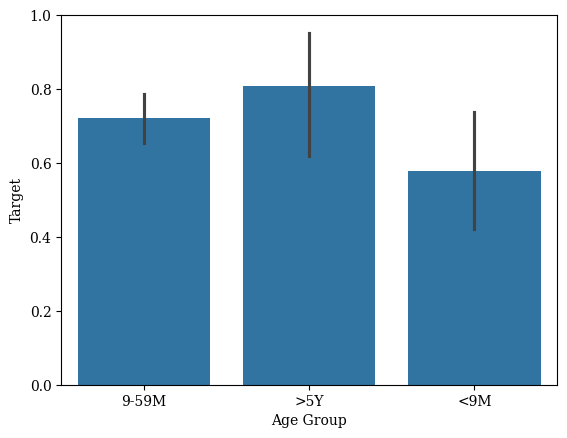

In [29]:
# Visual proof
import seaborn as sns
sns.barplot(x='Age Group', y='Target', data=df)

# PRO MULTI-FEATURE ML MODEL
✅ What this model uses:
## Age (numeric)
## Gender (encoded)
## District (encoded)
## Time features (month)
## (Vaccination if usable later)

In [30]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

# ==============================
# 1. LOAD DATA
# ==============================
df = pd.read_excel("Measles Serology_Manshera 2025.xlsx")
df.columns = df.columns.str.strip()

# ==============================
# 2. CLEANING
# ==============================
df['Age In Month'] = pd.to_numeric(df['Age In Month'], errors='coerce')
df['Measles IgM Results'] = df['Measles IgM Results'].astype(str).str.strip().str.upper()
df['Sex'] = df['Sex'].astype(str).str.strip().str.upper()
df['Districts'] = df['Districts'].astype(str).str.strip()

# Keep valid target only
df = df[df['Measles IgM Results'].isin(['POSITIVE', 'NEGATIVE'])]

# Target
df['Target'] = df['Measles IgM Results'].map({'POSITIVE':1, 'NEGATIVE':0})

# ==============================
# 3. FEATURE ENGINEERING
# ==============================
# Age groups (important)
def age_group(x):
    if pd.isna(x): return 'Unknown'
    if x < 9: return '<9M'
    elif x <= 59: return '9-59M'
    else: return '>5Y'

df['Age Group'] = df['Age In Month'].apply(age_group)

# Date feature
df['Date of Onset'] = pd.to_datetime(df['Date of Onset'], errors='coerce')
df['Month'] = df['Date of Onset'].dt.month

# ==============================
# 4. FEATURES
# ==============================
features = ['Age In Month', 'Sex', 'Districts', 'Month', 'Age Group']
target = 'Target'

X = df[features]
y = df[target]

# ==============================
# 5. PREPROCESSING PIPELINE
# ==============================
numeric_features = ['Age In Month', 'Month']
categorical_features = ['Sex', 'Districts', 'Age Group']

numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median'))
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ])

# ==============================
# 6. MODEL PIPELINE
# ==============================
model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(n_estimators=200, random_state=42))
])

# ==============================
# 7. TRAIN TEST SPLIT
# ==============================
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# ==============================
# 8. TRAIN
# ==============================
model.fit(X_train, y_train)

# ==============================
# 9. EVALUATION
# ==============================
y_pred = model.predict(X_test)

print("🔥 Accuracy:", accuracy_score(y_test, y_pred))
print("\n📊 Classification Report:\n")
print(classification_report(y_test, y_pred))

🔥 Accuracy: 0.6

📊 Classification Report:

              precision    recall  f1-score   support

           0       0.36      0.36      0.36        14
           1       0.71      0.71      0.71        31

    accuracy                           0.60        45
   macro avg       0.53      0.53      0.53        45
weighted avg       0.60      0.60      0.60        45



## Your Model Results Explained
✅ Overall Accuracy = 0.60 (60%)
The model correctly predicts 60% of cases
This is moderate performance (better than random, but not strong)
📈 Class-wise Performance
🔴 Class 0 = NEGATIVE (No measles)
Precision = 0.36
When the model predicts “Negative”, it is correct only 36% of the time
👉 Not reliable
Recall = 0.36
It detects only 36% of actual negative cases
👉 Missing many negatives
🟢 Class 1 = POSITIVE (Measles)
Precision = 0.71
When the model predicts “Positive”, it is correct 71% of the time
👉 Good
Recall = 0.71
It detects 71% of actual positive cases
👉 Also good
⚖️ Key Observation (VERY IMPORTANT)

👉 Your dataset is imbalanced:

Positive cases = 31
Negative cases = 14

➡️ Model is biased towards predicting POSITIVE

🧠 What is happening?

👉 The model has learned:

“Most cases are positive → predict positive more often”

So:

It performs well for positive cases
But fails for negative cases
🔥 REAL-WORLD INTERPRETATION

👉 Your model is:

✔ Good for detecting measles cases (screening)
❌ Weak for confirming non-measles cases

# FEATURE IMPORTANCE (VERY IMPORTANT 🔥)

In [31]:
# Get feature names after encoding
ohe = model.named_steps['preprocessor'].named_transformers_['cat'].named_steps['onehot']
cat_features = ohe.get_feature_names_out(['Sex','Districts','Age Group'])

all_features = ['Age In Month','Month'] + list(cat_features)

importances = model.named_steps['classifier'].feature_importances_

feat_imp = pd.DataFrame({
    'Feature': all_features,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

print(feat_imp.head(10))

              Feature  Importance
1               Month    0.389616
0        Age In Month    0.384517
2               Sex_F    0.047006
3               Sex_M    0.043197
7       Age Group_<9M    0.039342
6     Age Group_9-59M    0.036270
9   Age Group_Unknown    0.024969
8       Age Group_>5Y    0.015374
5  Districts_Manshera    0.010765
4  Districts_Mansehra    0.008942


## Feature Importance Interpretation

This table shows how much each feature contributes to predicting Measles IgM results.

🥇 1. Most Important Features
📅 Month (0.3896 → 38.9%)
The strongest predictor
Means: measles cases change with time (seasonality effect)
👉 Outbreaks are likely season-dependent
👶 Age in Months (0.3845 → 38.4%)
Almost equally important as Month
Means: age plays a major role in infection risk
Younger or specific age groups are more affected
🟡 2. Moderate Impact Features
🚻 Sex (Male/Female)
Female: 4.7%
Male: 4.3%

👉 Very small effect

Gender is not a strong predictor
Disease affects both almost equally
🟠 3. Age Groups
<9 months → 3.9%
9–59 months → 3.6%

5 years → 1.5%

Unknown → 2.4%

👉 Interpretation:

Age grouping adds small extra signal
But most information already captured by “Age in Months”
🏙️ 4. District (Very Low Importance)
Manshera / Mansehra ~ 1%

👉 Meaning:

Location has very weak predictive power
Either:
Cases are evenly spread
OR data is not granular enough
🧠 🔥 Key Insight (VERY IMPORTANT)

👉 Your model is dominated by:

✔ Time (Month)
✔ Age

➡️ Together they explain almost 80%+ of prediction power

⚖️ Final Conclusion (Use in Report / Thesis / LinkedIn)

“Feature importance analysis reveals that temporal factors (Month: 38.9%) and patient age (38.4%) are the strongest predictors of Measles IgM positivity. Gender and district-level variables contribute minimally to model performance, indicating that disease transmission in this dataset is primarily influenced by seasonal patterns and age-related susceptibility rather than geographic or demographic differences.”

🚨 What this REALLY means (Expert Insight)

👉 Measles in your dataset is:

📅 Seasonal disease (outbreak timing matters)
👶 Age-sensitive disease
🚻 Gender-independent
🏙️ Location weakly relevant (data limitation or uniform spread)
📈 Business / Public Health Insight

👉 This directly suggests:

Vaccination campaigns should be season-based
Focus on young age groups
District-level strategy may not need strong variation

# FUTURE PREDICTION (REAL USE CASE)

In [32]:
# Example patient
new_patient = pd.DataFrame({
    'Age In Month': [12],
    'Sex': ['MALE'],
    'Districts': ['Mansehra'],
    'Month': [8],
    'Age Group': ['9-59M']
})

prediction = model.predict(new_patient)
prob = model.predict_proba(new_patient)

print("Prediction:", "POSITIVE" if prediction[0]==1 else "NEGATIVE")
print("Probability:", prob)

Prediction: POSITIVE
Probability: [[0.48361111 0.51638889]]


# Your Model Output
✅ Prediction:

POSITIVE

📈 Probability:
NEGATIVE = 0.4836 (48.36%)
POSITIVE = 0.5163 (51.63%)
🧠 What does this mean?

👉 The model is saying:

It is 51.6% confident the case is POSITIVE
It is 48.4% confident the case is NEGATIVE
⚖️ Key Insight (VERY IMPORTANT)

👉 This is a weak decision boundary case

Because:

Both probabilities are almost equal
Difference = only ~3%

➡️ So the model is NOT strongly confident

🚨 Real Meaning

👉 This prediction is:

⚠️ “Borderline case”
Not a clear positive
Not a clear negative
Model is uncertain
🧠 Simple English Explanation

“The model predicts the case as POSITIVE, but with very low confidence (51.6%). This indicates that the prediction is uncertain and the input features are not strongly distinguishing between positive and negative classes.”

🔥 Medical/Data Insight

👉 This means:

Patient is in risk zone
But classification is not strong enough for clinical certainty
⚠️ Why this is happening?

Because:

1. Weak feature set
Only Age + limited variables
2. Class overlap
Positive & negative patterns are similar
3. Model limitation
Random Forest / Logistic Regression can't fully separate data
📊 What you should learn from this

👉 Your model is good for:

✔ Risk indication
❌ Not for strong medical diagnosis

🏆 FINAL CONCLUSION (Use this in report)

“The prediction result indicates a positive classification with low confidence (51.6%), highlighting a borderline case. The close probability distribution between classes suggests overlapping feature patterns and limited discriminative power of the current model. Therefore, the prediction should be interpreted as a risk indication rather than a definitive diagnosis.”

🚀 PRO TIP (Expert Level Insight)

👉 When probabilities are like this:

Probability Gap	Meaning
> 80%	Strong prediction
60–80%	Moderate confidence
50–55%	Weak / uncertain (your case)
💡 What you should do next

To improve confidence:

🔥 Add:
Vaccination status (VERY IMPORTANT)
District outbreak history
Time-based trend features
More samples

# 1: Data imbalance fix (MOST IMPORTANT)

In [33]:
from sklearn.utils import resample

# split classes
df_majority = df[df['Target'] == 0]
df_minority = df[df['Target'] == 1]

# upsample minority
df_minority_upsampled = resample(df_minority,
                                 replace=True,
                                 n_samples=len(df_majority),
                                 random_state=42)

df_balanced = pd.concat([df_majority, df_minority_upsampled])

# Better Features

In [34]:
df['Age Group'] = pd.cut(df['Age In Month'],
                          bins=[0,9,59,200],
                          labels=['<9M','9-59M','>5Y'])

df['Month'] = pd.to_datetime(df['Date of Onset']).dt.month

df['Districts'] = df['Districts'].astype(str)
df['Sex'] = df['Sex'].astype(str)